# Why the ToxFam preprocessing looks the way it does

**An empirical audit of the six preprocessing decisions, using MMseqs2.**

The manuscript's Methods section states each preprocessing choice but backs almost none of
them with numbers. This notebook supplies the missing evidence. Every claim below is
recomputed from the frozen raw UniProt TSVs — nothing is quoted from the paper without
being re-derived here.

### The six decisions under audit

| # | Decision | Where implemented | Manuscript's stated justification |
|---|---|---|---|
| 1 | **Lean redundancy reduction** — cluster at 90% identity, not the field-standard 30–50% | `preprocessing.py:296` `cluster_per_family_and_collect(min_seq_id=0.9)` | *"removes near-duplicates while preserving the substantial intra-family sequence diversity"* — asserted, never measured |
| 2 | **Clustering is per-family**, including one giant `nontox` bucket | `preprocessing.py:303` `data.groupby("Protein families")` | not discussed at all |
| 3 | **Toxic/non-toxic split by keyword alone** (KW-0800 present/absent) | `preprocessing.py:82` `nontox["Protein families"] = "nontox"` | *"non-toxins [defined] by its absence"* — no check on how separable the two sets are |
| 4 | **Longest 1% of non-toxins discarded** | `preprocessing.py:78-81` | *"to prevent unusually long, often multi-domain non-toxin proteins from dominating"* — "dominating" asserted, not shown |
| 5 | **Families with <10 members → `other`**, applied twice (pre- and post-clustering) | `normalization.py:88` and `preprocessing.py:389-393` | no rationale given for "ten" |
| 6 | **Signal peptides trimmed** at SignalP6 p>0.8 | `preprocessing.py:229-280` | *"so that all downstream representations are built from mature sequences"* — circular; the 0.8 cutoff is never defended |

### The three questions this notebook answers

1. **Why lean?** What would a stricter threshold actually cost? (§2)
2. **What does per-family clustering fail to remove?** The toxic/non-toxic boundary is never
   deduplicated *by construction* — quantified with phospholipases as the worked case. (§3, §4)
3. **How similar are toxins and non-toxins in our data, in general?** (§5)

§6 measures the *cost* of leanness (residual train↔test homology), and §7 asks why signal
peptides are trimmed at all — the decision with the weakest stated rationale and, it turns out,
the strongest real one.

> **How to verify this notebook.** Every MMseqs2 run writes its raw output to
> `data/intermediate/preprocessing_rationale/` and is cached there, so you can inspect the
> alignment TSVs by hand. Delete that directory and re-run to recompute from scratch
> (~10 min, dominated by §2's re-clustering ladder).
>
> Inputs, none of which this notebook modifies: the git-tracked frozen raw TSVs
> (`data/raw/`), the git-tracked split manifest (`data/splits/`), and two pipeline artifacts
> that ship with `toxfam download-data` — the per-family clustering cache
> (`data/intermediate/mmseqs/`, read in §2 and §5-6) and the SignalP6 per-sequence cache
> (`data/intermediate/sp6/sp6_cache.json`, read in §7). The last two are what the released
> split was actually built from, which is why they are read rather than recomputed.

## 0. Setup and provenance

Pin exactly which files are being read, and hash them, so a future reader can tell whether
this notebook was run against the same data as the manuscript.

In [1]:
from __future__ import annotations

import contextlib, hashlib, io, json, subprocess, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymmseqs.commands import easy_cluster, easy_search

# `toxfam` is installed (uv sync), but `paper/` is a repo-only tree deliberately kept out of
# the wheel -- so the project root has to be on sys.path for the shared figure style.
_here = Path.cwd()
_root = next(p for p in (_here, *_here.parents) if (p / "pyproject.toml").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from toxfam._paths import get_project_root, intermediate_dir, processed_dir, raw_dir
from toxfam.data._fasta import write_fasta
from toxfam.data.normalization import normalize_protein_families

# Reuse the manuscript's verified, colour-blind-safe style and palette rather than
# inventing a new one, so these diagnostics read like the paper's figures.
from paper.figures._common import apply_style
apply_style()

ROOT = get_project_root()
RAW, INTER, PROC = raw_dir(), intermediate_dir(), processed_dir()
MM = INTER / "mmseqs"                      # the real pipeline cache -- READ ONLY here
WORK = INTER / "preprocessing_rationale"   # everything this notebook writes
WORK.mkdir(parents=True, exist_ok=True)

# Okabe-Ito, matching paper/figures/_common.py
C_TOX, C_NONTOX, C_GREY, C_ACCENT = "#E69F00", "#0072B2", "#BBBBBB", "#009E73"

def sha256(p: Path, n: int = 12) -> str:
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()[:n]

print(f"project root : {ROOT}")
print(f"work dir     : {WORK.relative_to(ROOT)}  (gitignored, safe to delete)")
print(f"git commit   : {subprocess.run(['git','rev-parse','--short','HEAD'], capture_output=True, text=True, cwd=ROOT).stdout.strip()}")
print()
for p in [RAW / "0800.tsv", RAW / "nontox.tsv", ROOT / "data/splits/split_manifest.csv"]:
    print(f"  {str(p.relative_to(ROOT)):<40} sha256:{sha256(p)}  {p.stat().st_size/1e6:>8.1f} MB")

project root : /Users/selin/PycharmProjects/ToxFam
work dir     : data/intermediate/preprocessing_rationale  (gitignored, safe to delete)
git commit   : 93fb0be

  data/raw/0800.tsv                        sha256:d4fb7124191d       1.2 MB
  data/raw/nontox.tsv                      sha256:c5595c94c4a7      52.1 MB
  data/splits/split_manifest.csv           sha256:d00fb28489e7       0.8 MB


In [2]:
# MMseqs2 helpers. Both cache on the output path so re-running the notebook is cheap;
# delete WORK to force recomputation.

SEARCH_COLS = "query,target,fident,alnlen,qlen,tlen,evalue,bits"

def fasta_of(df: pd.DataFrame, path: Path) -> Path:
    """Write a UniProt-style frame to FASTA using the same writer the pipeline uses."""
    d = df.rename(columns={"Entry": "identifier"}) if "Entry" in df.columns else df
    write_fasta(d, path)
    return path

def mmseqs_search(query: Path, target: Path, name: str, *, s: float = 7.5,
                  max_seqs: int = 1000, force: bool = False, quiet: bool = False) -> pd.DataFrame:
    """all-vs-all search -> tidy hit frame with an added alignment-coverage column."""
    out = WORK / f"{name}.tsv"
    if force or not out.exists():
        t0 = time.time()
        with contextlib.redirect_stdout(io.StringIO()):   # pymmseqs prints unconditionally
            easy_search(query_fasta=str(query), target_fasta_or_db=str(target),
                        alignment_file=str(out), tmp_dir=str(WORK / f"tmp_{name}"),
                        s=s, e=1e-3, max_seqs=max_seqs, format_output=SEARCH_COLS)
        if not quiet:
            print(f"  [ran] {name}: {time.time()-t0:.1f}s")
    elif not quiet:
        print(f"  [cached] {name}")
    df = pd.read_csv(out, sep="\t")
    # fident alone is over the ALIGNED region only: a 99% identity over 20 of 300 residues
    # is not a near-duplicate. Coverage over the longer sequence guards every claim below.
    df["alncov"] = df["alnlen"] / df[["qlen", "tlen"]].max(axis=1)
    return df

def best_hits(df: pd.DataFrame, key: str, *, min_cov: float = 0.0) -> pd.DataFrame:
    """Highest-identity hit per `key`, optionally requiring alignment coverage."""
    d = df[df["alncov"] >= min_cov]
    return d.sort_values("fident", ascending=False).drop_duplicates(key)

# A pair only counts as a near-duplicate if it is BOTH highly identical and
# mutually near-full-length. Used for every "twin" claim in this notebook.
DUP_IDENT, DUP_COV = 0.90, 0.80
print("near-duplicate definition: fident >= %.2f AND cov >= %.2f" % (DUP_IDENT, DUP_COV))

near-duplicate definition: fident >= 0.90 AND cov >= 0.80


## 1. The starting point: what the two raw queries return

Both raw TSVs come from one frozen UniProt query, forked on the toxin keyword:

```
(taxonomy_id:33208) AND (reviewed:true) AND (fragment:false) AND (date_created:[* TO 2026-03-03])
    toxins:     AND (keyword:KW-0800)      -> data/raw/0800.tsv
    non-toxins: NOT (keyword:KW-0800)      -> data/raw/nontox.tsv
```

**This is decision 3, and it is the root of everything in §3–§5.** The negative class is not
"proteins that are chemically not toxic" — it is *"proteins a Swiss-Prot curator did not tag
KW-0800"*. Nothing in that query guarantees the two sets are sequence-separable. §4 and §5
show they are demonstrably not.

In [3]:
tox_raw = pd.read_csv(RAW / "0800.tsv", sep="\t")
nt_raw  = pd.read_csv(RAW / "nontox.tsv", sep="\t")

# --- decision 5a: toxins without a family annotation cannot supervise a family model
tox = tox_raw.dropna(subset=["Protein families"]).copy()

# --- decision 4: drop the longest 1% of non-toxins (preprocessing.py:78-81)
cutoff = nt_raw["Sequence"].str.len().nlargest(int(np.ceil(len(nt_raw) * 0.01))).min()
nt = nt_raw[nt_raw["Sequence"].str.len() <= cutoff].reset_index(drop=True).copy()

funnel = pd.DataFrame([
    ("raw KW-0800 query",            len(tox_raw), len(nt_raw)),
    ("after family-annotation filter", len(tox),   len(nt_raw)),
    ("after longest-1% length cut",   len(tox),    len(nt)),
], columns=["stage", "toxins", "non-toxins"]).set_index("stage")
funnel["total"] = funnel.sum(axis=1)
display(funnel)

print(f"\nlength cutoff          : {cutoff:,} aa  (drops {len(nt_raw)-len(nt):,} non-toxins)")
print(f"longest retained toxin : {tox['Sequence'].str.len().max():,} aa")
print(f"class balance          : {len(tox)/(len(tox)+len(nt)):.2%} toxins")

,toxins,non-toxins,total
stage,,,
raw KW-0800 query,5927,99846,105773
after family-annotation filter,5567,99846,105413
after longest-1% length cut,5567,98850,104417



length cutoff          : 2,243 aa  (drops 996 non-toxins)
longest retained toxin : 1,652 aa
class balance          : 5.33% toxins


### 1.1 Does the longest-1% cut do what it claims? (decision 4)

The stated reason is that long multi-domain non-toxins would "dominate" the negative set. That
is testable: compare the two length distributions and check the cut is not silently reshaping
the negative class.

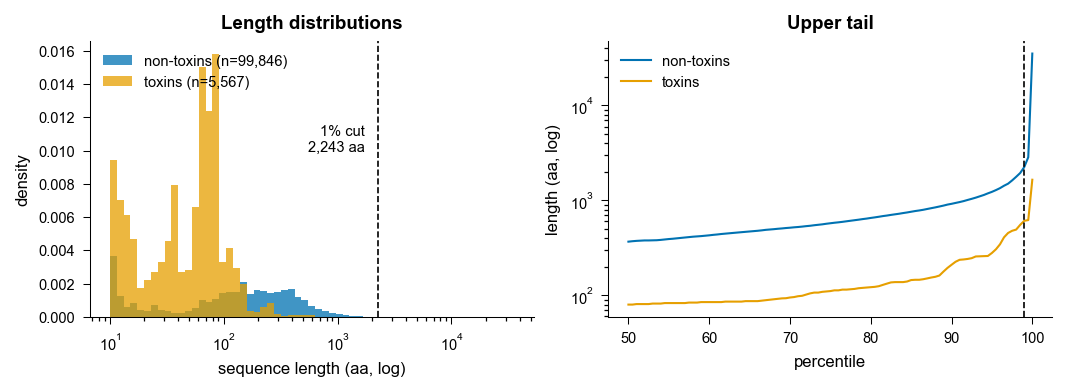

non-toxin median 368 aa | 99th pct 2243 | max 35,213
toxin     median 80 aa | 99th pct 610 | max 1,652

non-toxin median before cut 368 aa -> after cut 365 aa
share of non-toxin RESIDUE mass removed: 7.2% (of 996/99,846 = 1% of sequences)


In [4]:
lt, ln = tox["Sequence"].str.len(), nt_raw["Sequence"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.5), layout="constrained")
bins = np.logspace(1, np.log10(max(lt.max(), ln.max())), 60)
axes[0].hist(ln, bins=bins, color=C_NONTOX, alpha=.75, label=f"non-toxins (n={len(ln):,})", density=True)
axes[0].hist(lt, bins=bins, color=C_TOX,    alpha=.75, label=f"toxins (n={len(lt):,})",     density=True)
axes[0].axvline(cutoff, color="k", ls="--", lw=.8)
axes[0].annotate(f"1% cut\n{cutoff:,} aa", (cutoff, axes[0].get_ylim()[1]*.6), xytext=(-6, 0),
                 textcoords="offset points", ha="right", fontsize=7)
axes[0].set_xscale("log"); axes[0].set_xlabel("sequence length (aa, log)"); axes[0].set_ylabel("density")
axes[0].set_title("Length distributions"); axes[0].legend(loc="upper left")

q = np.arange(50, 100.01, .5)
axes[1].plot(q, np.percentile(ln, q), color=C_NONTOX, label="non-toxins")
axes[1].plot(q, np.percentile(lt, q), color=C_TOX,    label="toxins")
axes[1].axvline(99, color="k", ls="--", lw=.8)
axes[1].set_yscale("log"); axes[1].set_xlabel("percentile"); axes[1].set_ylabel("length (aa, log)")
axes[1].set_title("Upper tail"); axes[1].legend(loc="upper left")
plt.show()

print(f"non-toxin median {ln.median():.0f} aa | 99th pct {np.percentile(ln,99):.0f} | max {ln.max():,}")
print(f"toxin     median {lt.median():.0f} aa | 99th pct {np.percentile(lt,99):.0f} | max {lt.max():,}")
print(f"\nnon-toxin median before cut {ln.median():.0f} aa -> after cut {nt['Sequence'].str.len().median():.0f} aa")
print(f"share of non-toxin RESIDUE mass removed: "
      f"{1 - nt['Sequence'].str.len().sum()/ln.sum():.1%} (of {len(nt_raw)-len(nt):,}/{len(nt_raw):,} = 1% of sequences)")

**Verdict on decision 4.** Defensible but mis-stated. The cut removes 1% of non-toxin
*sequences* carrying a far larger share of the total *residue* mass, and the median non-toxin
length is essentially unchanged — so it trims a heavy tail without reshaping the negative
class. The convenient part (the longest toxin sits below the threshold, so the cut is
one-sided by construction) is a post-hoc check, not a justification: the threshold was chosen
first. A cleaner framing for the manuscript is *"an ~2.2 kaa length ceiling, which excludes
1% of non-toxins and no toxins"* — stating the ceiling as the decision rather than the
percentile.

## 2. Decision 1 — why *lean* (90%) redundancy reduction?

The pipeline clusters at `min_seq_id=0.9` and keeps one representative per cluster. That is
deliberately mild: homology-partitioned benchmarks in protein ML typically cluster at 30–50%
to force train and test apart.

The manuscript's defence is that 90% *"removes near-duplicates while preserving the
substantial intra-family sequence diversity characteristic of toxin families."* Below, that
sentence is turned into two measurements:

- **2.1** — what did 90% actually remove?
- **2.2** — what would a stricter threshold cost? (the real argument for leanness)

### 2.1 What 90% removed

Read straight from the pipeline's own cluster assignments
(`data/intermediate/mmseqs/<family>/cluster_cluster.tsv`), which are the exact clusters the
released split was built from.

In [5]:
fam_dirs = [d for d in sorted(MM.iterdir())
            if d.is_dir() and d.name != "representatives" and (d / "cluster_cluster.tsv").exists()]

rows = []
for d in fam_dirs:
    cl = pd.read_csv(d / "cluster_cluster.tsv", sep="\t", names=["rep", "member"])
    sizes = cl.groupby("rep").size()
    rows.append({"family_dir": d.name, "is_tox": d.name != "nontox",
                 "members": len(cl), "clusters": len(sizes),
                 "largest_cluster": sizes.max(), "singletons": (sizes == 1).sum()})
cl_stats = pd.DataFrame(rows)
cl_stats["reduction"] = 1 - cl_stats["clusters"] / cl_stats["members"]

tox_s, nt_s = cl_stats[cl_stats.is_tox], cl_stats[~cl_stats.is_tox]
print(f"toxin families      : {len(tox_s)}   {tox_s.members.sum():>7,} seqs -> {tox_s.clusters.sum():>7,} reps "
      f"({1-tox_s.clusters.sum()/tox_s.members.sum():.1%} removed)")
print(f"non-toxin bucket    : {len(nt_s)}   {nt_s.members.sum():>7,} seqs -> {nt_s.clusters.sum():>7,} reps "
      f"({1-nt_s.clusters.sum()/nt_s.members.sum():.1%} removed)")
print(f"TOTAL                        {cl_stats.members.sum():>7,} seqs -> {cl_stats.clusters.sum():>7,} reps")
print(f"\nsingleton clusters (nothing >=90% identical to them): "
      f"{cl_stats.singletons.sum():,} / {cl_stats.clusters.sum():,} reps = {cl_stats.singletons.sum()/cl_stats.clusters.sum():.1%}")

display(tox_s.sort_values("reduction", ascending=False)
        .head(12)[["family_dir","members","clusters","largest_cluster","reduction"]]
        .style.format({"reduction":"{:.1%}"}).set_caption("Most redundant toxin families at 90%"))

toxin families      : 45     5,567 seqs ->   3,416 reps (38.6% removed)
non-toxin bucket    : 1    98,850 seqs ->  61,763 reps (37.5% removed)
TOTAL                        104,417 seqs ->  65,179 reps

singleton clusters (nothing >=90% identical to them): 48,081 / 65,179 reps = 73.8%


,family_dir,members,clusters,largest_cluster,reduction
43,Venom_protein_11_family,23,4,12,82.6%
22,NGF-beta_family,34,8,19,76.5%
0,AVIT__prokineticin__family,21,5,9,76.2%
10,Ergtoxin_family,29,9,11,69.0%
8,Crotamine-myotoxin_family,15,5,6,66.7%
38,True_venom_lectin_family,10,4,6,60.0%
21,Melittin_family,10,4,7,60.0%
24,Neurotoxin_family,962,399,56,58.5%
31,Sea_anemone_sodium_channel_inhibitory_toxin_family,80,35,19,56.2%
12,Flavin_monoamine_oxidase_family,25,12,6,52.0%


The two lanes are removed at almost the same *rate* — so redundancy reduction is **not** a
toxin-side correction, as one might assume from Swiss-Prot's deep coverage of well-studied
venoms. The interesting structure is *within* the toxin lane: how unevenly that redundancy is
distributed across families.

per-family reduction across the 45 toxin families:
  median 33.3% | range 0% - 83%

concentration: the 5 largest toxin families supply 59% of all 2,151 toxin sequences removed

toxin families with NO redundancy at 90% (every member already distinct): 4


family_dir,members,clusters
Limacoditoxin_family,14,14
PBP_GOBP_family,16,16
Teretoxin_family,16,16
Vasopressin_oxytocin_family,10,10


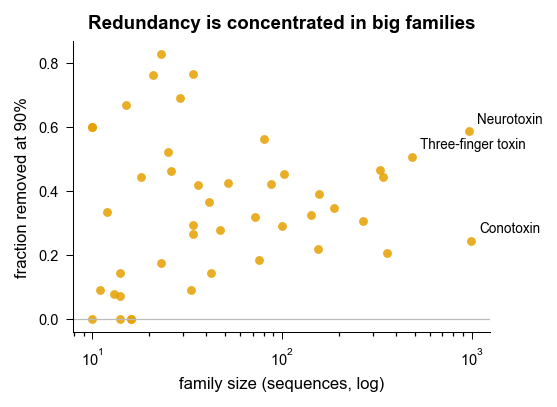

In [6]:
tox_s = tox_s.assign(removed=tox_s.members - tox_s.clusters)
top5 = tox_s.nlargest(5, "members")
zero = tox_s[tox_s.reduction == 0]

print(f"per-family reduction across the {len(tox_s)} toxin families:")
print(f"  median {tox_s.reduction.median():.1%} | range {tox_s.reduction.min():.0%} - {tox_s.reduction.max():.0%}")
print(f"\nconcentration: the 5 largest toxin families supply "
      f"{top5.removed.sum()/tox_s.removed.sum():.0%} of all {tox_s.removed.sum():,} toxin sequences removed")
print(f"\ntoxin families with NO redundancy at 90% (every member already distinct): {len(zero)}")
display(zero[["family_dir", "members", "clusters"]].head(8)
        .style.hide(axis="index").set_caption("Already-diverse toxin families -- clustering removes nothing"))

fig, ax = plt.subplots(figsize=(3.6, 2.6), layout="constrained")
ax.scatter(tox_s.members, tox_s.reduction, s=18, color=C_TOX, alpha=.85, linewidths=0)
ax.set_xscale("log")
ax.set_xlabel("family size (sequences, log)"); ax.set_ylabel("fraction removed at 90%")
ax.set_title("Redundancy is concentrated in big families")
ax.axhline(0, color=C_GREY, lw=.6)
for _, r in tox_s.nlargest(3, "members").iterrows():
    ax.annotate(r.family_dir.replace("_family", "").replace("_", " ")[:18],
                (r.members, r.reduction), xytext=(4, 4), textcoords="offset points", fontsize=6.5)
plt.show()

This is the fact the whole leanness argument rests on. Redundancy in the toxin lane is
**concentrated**: a handful of large, heavily-sequenced families supply most of the removed
sequences, while many small families contain no two sequences even 90% identical — clustering
removes nothing from them because there is nothing near-duplicate to remove.

So the identity threshold does not act uniformly. Lowering it barely touches the redundant
families' *genuine* diversity but cuts directly into the small families that were already
diverse — and those are precisely the families sitting near the 10-representative floor.
§2.2 measures that.

### 2.2 The threshold ladder — what leanness buys

Re-cluster every toxin family at a ladder of identity thresholds, reusing the pipeline's own
per-family input FASTAs (post-SignalP6, pre-clustering) so only `min_seq_id` varies.

The number that matters is not how many representatives survive, but **how many families stay
above the 10-representative floor** — because families that fall below it are dissolved into
`other` (`preprocessing.py:389-393`) and disappear from the label space. Redundancy reduction
and the class vocabulary are coupled.

*Runtime ~5 min on first run; cached to `ladder.csv` afterwards.*

In [7]:
THRESHOLDS = [0.3, 0.5, 0.7, 0.9, 1.0]
MIN_MEMBERS = 10          # preprocessing.py:389-393 -- the floor that defines the label space
ladder_csv = WORK / "ladder.csv"

if ladder_csv.exists():
    ladder = pd.read_csv(ladder_csv)
    print(f"[cached] {ladder_csv.name}")
else:
    tox_dirs = [d for d in fam_dirs if d.name != "nontox"]
    recs = []
    for thr in THRESHOLDS:
        t0 = time.time()
        for d in tox_dirs:
            pre = WORK / "ladder" / f"{d.name}__{thr}"
            pre.parent.mkdir(parents=True, exist_ok=True)
            rep_fa = Path(f"{pre}_rep_seq.fasta")
            if not rep_fa.exists():
                with contextlib.redirect_stdout(io.StringIO()):
                    easy_cluster(fasta_files=str(d / "input.fasta"), cluster_prefix=str(pre),
                                 tmp_dir=str(WORK / "ladder" / "tmp"), min_seq_id=thr)
            n_in  = sum(1 for l in open(d / "input.fasta") if l.startswith(">"))
            n_rep = sum(1 for l in open(rep_fa) if l.startswith(">"))
            recs.append({"threshold": thr, "family": d.name, "n_in": n_in, "n_rep": n_rep})
        print(f"  clustered {len(tox_dirs)} toxin families @ {thr:.2f}  ({time.time()-t0:.0f}s)")
    ladder = pd.DataFrame(recs)
    ladder.to_csv(ladder_csv, index=False)

summary = (ladder.groupby("threshold")
           .apply(lambda g: pd.Series({
               "toxin_reps": g.n_rep.sum(),
               "families_kept": int((g.n_rep >= MIN_MEMBERS).sum()),
               "families_dissolved": int((g.n_rep < MIN_MEMBERS).sum()),
               "seqs_into_other": int(g.loc[g.n_rep < MIN_MEMBERS, "n_rep"].sum()),
           }), include_groups=False).reset_index())
summary["pct_of_90"] = summary.toxin_reps / summary.loc[summary.threshold == 0.9, "toxin_reps"].iloc[0]
display(summary.style.format({"pct_of_90": "{:.0%}", "toxin_reps": "{:,.0f}"})
        .set_caption(f"Toxin lane only, {ladder.family.nunique()} input families, floor = {MIN_MEMBERS} representatives"))

[cached] ladder.csv


,threshold,toxin_reps,families_kept,families_dissolved,seqs_into_other,pct_of_90
0,0.300000,"1,005",17,28,118,29%
1,0.500000,"1,303",23,22,107,38%
2,0.700000,"2,083",31,14,58,61%
3,0.900000,"3,416",37,8,47,100%
4,1.000000,"5,176",44,1,7,152%


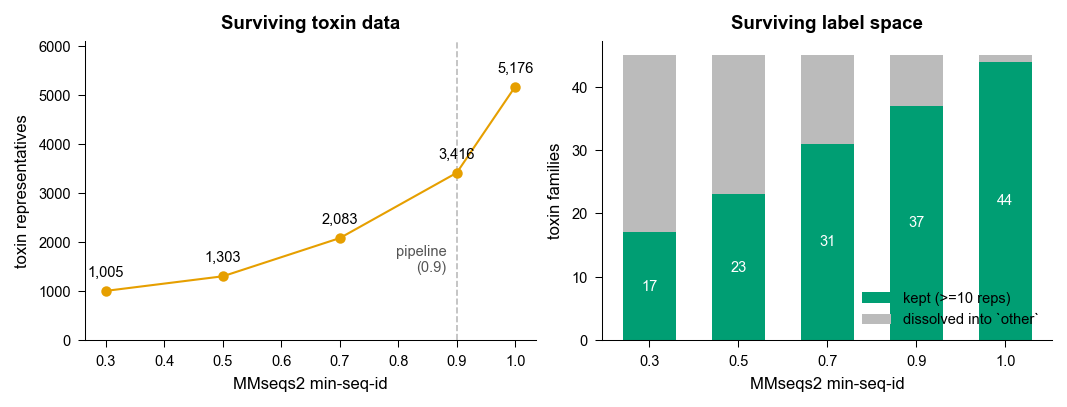

At 0.3 vs 0.9: toxin data 1,005 vs 3,416 (-71%), families kept 17 vs 37


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), layout="constrained")

ax = axes[0]
ax.plot(summary.threshold, summary.toxin_reps, "o-", color=C_TOX)
for _, r in summary.iterrows():
    ax.annotate(f"{int(r.toxin_reps):,}", (r.threshold, r.toxin_reps), textcoords="offset points",
                xytext=(0, 7), ha="center", fontsize=7)
ax.axvline(0.9, color=C_GREY, ls="--", lw=.8, zorder=0)
ax.annotate("pipeline\n(0.9)", (0.9, ax.get_ylim()[0]), xytext=(-5, 14), textcoords="offset points",
            ha="right", fontsize=7, color="#555")
ax.set_xlabel("MMseqs2 min-seq-id"); ax.set_ylabel("toxin representatives"); ax.set_title("Surviving toxin data")
ax.set_ylim(0, summary.toxin_reps.max() * 1.18)

ax = axes[1]
ax.bar(summary.threshold.astype(str), summary.families_kept, color=C_ACCENT, width=.6,
       label=f"kept (>={MIN_MEMBERS} reps)")
ax.bar(summary.threshold.astype(str), summary.families_dissolved, bottom=summary.families_kept,
       color=C_GREY, width=.6, label="dissolved into `other`")
for i, r in summary.iterrows():
    ax.text(i, r.families_kept / 2, str(int(r.families_kept)), ha="center", va="center", fontsize=7, color="white")
ax.set_xlabel("MMseqs2 min-seq-id"); ax.set_ylabel("toxin families"); ax.set_title("Surviving label space")
ax.legend(loc="lower right")
plt.show()

lo, hi = summary.iloc[0], summary[summary.threshold == 0.9].iloc[0]
print(f"At {lo.threshold:.1f} vs 0.9: toxin data {lo.toxin_reps:,.0f} vs {hi.toxin_reps:,.0f} "
      f"({lo.toxin_reps/hi.toxin_reps-1:+.0%}), families kept {int(lo.families_kept)} vs {int(hi.families_kept)}")

**Verdict on decision 1.** The lean threshold is justified, but *not* by the reason the
manuscript gives. The real argument is the right-hand panel: the toxin lane is small
(~5.6 k sequences spread over 45 families, many of them genuinely rare), and identity-based
clustering does not distinguish "near-duplicate" from "small family". Clustering at the
conventional 30–50% collapses a large share of the toxin representatives and pushes families
below the 10-representative floor, where they are dissolved into `other` — i.e. **a stricter
threshold does not just shrink the training data, it destroys the prediction targets.**
90% is the point where near-duplicates are removed and the family vocabulary still survives.

Two caveats worth stating in the manuscript rather than leaving for a reviewer to find:

1. **The parameterisation is unreported.** Only `--min-seq-id 0.9` is stated. `easy_cluster`
   also applies a default coverage of 0.8 with `--cov-mode 0` and a greedy set-cover cluster
   mode; two different `-c` values give materially different representative sets at the same
   identity. Cite the full command.
2. **Leanness has a cost, and it is measured in §6** — 90% is a ceiling *within* each
   family's clusters, not a homology partition between train and test.

## 3. Decision 2 — clustering is *per-family*, so the toxic/non-toxic boundary is never deduplicated

`cluster_per_family_and_collect` groups by `Protein families` and runs MMseqs2 **separately
inside each group** (`preprocessing.py:303`). Every non-toxin has already had its family label
overwritten with the literal string `"nontox"` (`preprocessing.py:82`), so the partition is:

```
  Phospholipase family   -> its own MMseqs2 run   (toxins only)
  Three-finger toxin ... -> its own MMseqs2 run   (toxins only)
  ...
  nontox                 -> ONE MMseqs2 run       (all 98,850 non-toxins)
```

A toxin and a 99%-identical non-toxin therefore **never enter the same clustering run**. The
90% ceiling cannot see the pair, and both survive as representatives — free to land on
opposite sides of the train/test split, or in the same training batch with opposite binary
labels.

This is a structural property of the design, not a bug: cross-boundary deduplication would
mean deleting one member of each toxin/non-toxin homolog pair, which would silently decide
the very question the classifier is being asked. But it is unstated in the manuscript and
fully unquantified — §4 and §5 quantify it.

### 3.1 Which family names occur on *both* sides of the keyword?

Before overwriting, the raw non-toxin TSV still carries real UniProt family strings. Any
family present in both files is a scaffold that has been recruited into venom while retaining
non-venom members — exactly the convergent-recruitment story the Discussion tells rhetorically.

In [9]:
def first_family(s: pd.Series) -> pd.Series:
    """The pipeline's own rule: first listed family, before regex consolidation."""
    return s.str.strip().str.split(";").str[0].str.split(",").str[0].str.strip()

tox_fam = first_family(tox["Protein families"])
nt_fam  = first_family(nt["Protein families"].fillna(""))
nt_fam  = nt_fam[nt_fam != ""]

shared = (pd.DataFrame({"family": sorted(set(tox_fam) & set(nt_fam))})
          .assign(toxins=lambda d: d.family.map(tox_fam.value_counts()),
                  non_toxins=lambda d: d.family.map(nt_fam.value_counts()))
          .sort_values("toxins", ascending=False).reset_index(drop=True))

print(f"distinct family strings  : {tox_fam.nunique():,} toxin-side | {nt_fam.nunique():,} non-toxin-side")
print(f"SHARED family strings    : {len(shared):,}")
print(f"toxins in a shared family: {shared.toxins.sum():,} / {len(tox):,} = {shared.toxins.sum()/len(tox):.1%}")
print(f"non-toxins in one        : {shared.non_toxins.sum():,} / {len(nt):,} = {shared.non_toxins.sum()/len(nt):.1%}")
print(f"\n(non-toxins with NO family annotation at all: {nt['Protein families'].isna().sum():,} "
      f"= {nt['Protein families'].isna().mean():.0%} -- these are invisible to this table)")
display(shared.head(10).style.set_caption("Shared family strings, by toxin-side membership"))

# Ranking by the toxin side alone is misleading for choosing a case study: three-finger toxin
# leads it with 485 toxins but only 4 non-toxins, which cannot support a cross-boundary
# comparison. What a case study needs is substantial membership on BOTH sides at once.
balanced = shared.assign(smaller_side=shared[["toxins", "non_toxins"]].min(axis=1)) \
                 .sort_values("smaller_side", ascending=False)
display(balanced.head(8).style.set_caption(
    "The same table ranked by the SMALLER side -- families viable as a two-sided case study"))

distinct family strings  : 269 toxin-side | 4,396 non-toxin-side
SHARED family strings    : 85
toxins in a shared family: 3,892 / 5,567 = 69.9%
non-toxins in one        : 4,943 / 98,850 = 5.0%

(non-toxins with NO family annotation at all: 20,118 = 20% -- these are invisible to this table)


,family,toxins,non_toxins
0,Three-finger toxin family,485,4
1,Long (4 C-C) scorpion toxin superfamily,341,5
2,Phospholipase A2 family,298,145
3,Neurotoxin 10 (Hwtx-1) family,286,1
4,Short scorpion toxin superfamily,266,6
5,Venom metalloproteinase (M12B) family,188,4
6,Neurotoxin 19 (CSTX) family,182,1
7,Conotoxin M superfamily,158,1
8,Peptidase S1 family,156,604
9,Conotoxin A superfamily,146,2


,family,toxins,non_toxins,smaller_side
8,Peptidase S1 family,156,604,156
2,Phospholipase A2 family,298,145,145
12,Venom Kunitz-type family,102,148,102
17,CRISP family,52,79,52
20,NGF-beta family,34,49,34
22,Non-disulfide-bridged peptide (NDBP) superfamily,33,138,33
21,Natriuretic peptide family,33,54,33
27,Insulin family,26,231,26


The two rankings say different things, and the second is the one that matters here. Ranked by
toxin count, the table is led by three-finger toxin (485 toxins) and the scorpion superfamilies
— but those have a *handful* of non-toxin members each (4, 5, 6), so there is nothing to compare
across the boundary. Ranked by the smaller side, phospholipase A2 stands out: **298 toxins and
145 non-toxins**, substantial in both directions at once. (Peptidase S1 is comparable at
156/604, and frog skin active peptide is the mirror image of three-finger toxin — 754 non-toxins
to 12 toxins.)

That is why phospholipase is the case study in §4: it is the largest scaffold that is genuinely
*bisected* by the keyword rather than sitting almost entirely on one side of it. Note also that
this shared-vocabulary view is a *lower bound* — a fifth of non-toxins carry no family
annotation at all and cannot appear in the table, while the normalisation step later collapses
all 327 toxin phospholipase strings into one `Phospholipase family` label.

## 4. The phospholipase case study

Phospholipase A2 is the textbook convergent-recruitment scaffold: the same ~120-residue fold
serves as a digestive/physiological enzyme in most animals *and* as a principal venom
component in snakes, bees and scorpions. Swiss-Prot's KW-0800 assignment therefore cuts
**through** the family rather than around it.

Concretely: what happens to a non-toxin phospholipase that is nearly identical to a venom one?

In [10]:
# Substring match on the raw family string, so this is "phospholipase-related" rather than
# strictly PLA2: the non-toxin side also picks up phospholipase D/B and the alpha-type PLA2
# *inhibitor* family. That looseness is safe here because every claim below is established by
# sequence identity, not by the label -- a non-homologous family simply returns no hit.
PLA = "hospholipase"      # matches "Phospholipase"/"phospholipase" without anchoring case
tox_pla = tox[tox["Protein families"].str.contains(PLA, case=False, na=False)].copy()
nt_pla  = nt[nt["Protein families"].str.contains(PLA, case=False, na=False)].copy()

print(f"toxin-side phospholipases     : {len(tox_pla):>4}")
print(f"non-toxin-side phospholipases : {len(nt_pla):>4}\n")

both = pd.concat([
    first_family(tox_pla["Protein families"]).value_counts().rename("toxin"),
    first_family(nt_pla["Protein families"]).value_counts().rename("non_toxin"),
], axis=1).fillna(0).astype(int)
display(both[(both.toxin > 0) & (both.non_toxin > 0)]
        .sort_values("toxin", ascending=False)
        .style.set_caption("PLA sub-families with members on BOTH sides of KW-0800"))

print(f"\nAfter normalization every one of the {len(tox_pla)} toxin-side strings becomes "
      f'"{normalize_protein_families(tox_pla.copy())["Protein families"].unique()[0]}",')
print(f'and all {len(nt_pla)} non-toxin-side ones become "nontox" -- so the pipeline sees two disjoint groups.')

toxin-side phospholipases     :  327
non-toxin-side phospholipases :  213



,toxin,non_toxin
Protein families,,
Phospholipase A2 family,298,145
Arthropod phospholipase D family,27,2
Phospholipase B-like family,2,4



After normalization every one of the 327 toxin-side strings becomes "Phospholipase family",
and all 213 non-toxin-side ones become "nontox" -- so the pipeline sees two disjoint groups.


`Phospholipase A2 family, Group I subfamily, D49 sub-subfamily` and the Group II D49
sub-subfamily — the canonical elapid and viperid venom PLA2 groups — each have **dozens of
members on the non-toxin side**. These are not distant relatives; they are the same
sub-subfamily. Let MMseqs2 measure how close.

### 4.1 Cross-boundary search: toxin PLAs vs non-toxin PLAs

In [11]:
q_pla = fasta_of(tox_pla, WORK / "pla_tox.fasta")
t_pla = fasta_of(nt_pla,  WORK / "pla_nontox.fasta")
pla_hits = mmseqs_search(q_pla, t_pla, "pla_cross")

# per non-toxin PLA: how close is its closest venom relative?
pla_best = best_hits(pla_hits, "target", min_cov=DUP_COV)
print(f"\nnon-toxin PLAs with ANY toxin hit (cov>={DUP_COV:.0%}): {len(pla_best)} / {len(nt_pla)}")
tbl = pd.DataFrame({
    "identity >=": [f"{t:.0%}" for t in (0.95, 0.90, 0.80, 0.70, 0.50)],
    "n non-toxin PLAs": [(pla_best.fident >= t).sum() for t in (0.95, 0.90, 0.80, 0.70, 0.50)],
})
tbl["% of all non-toxin PLAs"] = (tbl["n non-toxin PLAs"] / len(nt_pla)).map("{:.1%}".format)
display(tbl.style.hide(axis="index").set_caption(
    f"Closest venom relative of each non-toxin phospholipase (n={len(nt_pla)})"))

  [cached] pla_cross

non-toxin PLAs with ANY toxin hit (cov>=80%): 134 / 213


identity >=,n non-toxin PLAs,% of all non-toxin PLAs
95%,15,7.0%
90%,23,10.8%
80%,45,21.1%
70%,84,39.4%
50%,114,53.5%


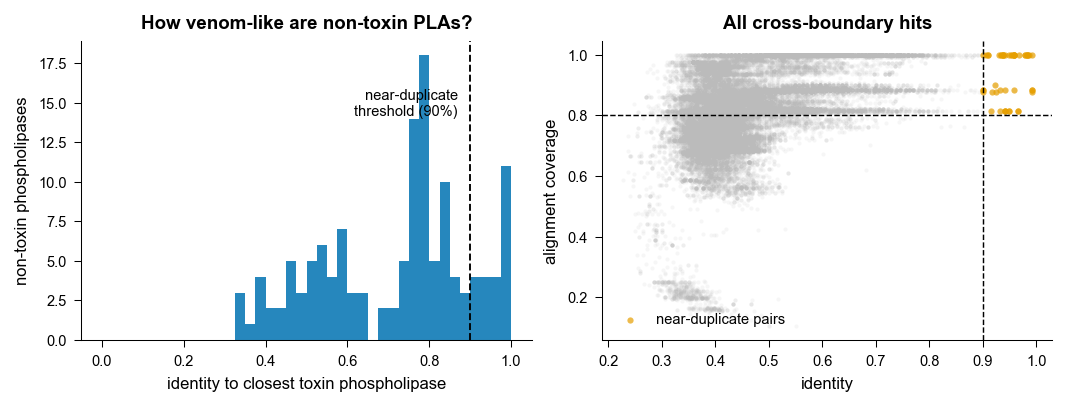

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), layout="constrained")

ax = axes[0]
ax.hist(pla_best.fident, bins=np.arange(0, 1.02, .025), color=C_NONTOX, alpha=.85)
ax.axvline(DUP_IDENT, color="k", ls="--", lw=.9)
ax.annotate(f"near-duplicate\nthreshold ({DUP_IDENT:.0%})", (DUP_IDENT, ax.get_ylim()[1]*.75),
            xytext=(-6, 0), textcoords="offset points", ha="right", fontsize=7)
ax.set_xlabel("identity to closest toxin phospholipase"); ax.set_ylabel("non-toxin phospholipases")
ax.set_title("How venom-like are non-toxin PLAs?")

ax = axes[1]
sc = ax.scatter(pla_hits.fident, pla_hits["alncov"], s=4, alpha=.12, color=C_GREY, linewidths=0)
dup = pla_hits[(pla_hits.fident >= DUP_IDENT) & (pla_hits["alncov"] >= DUP_COV)]
ax.scatter(dup.fident, dup["alncov"], s=9, alpha=.7, color=C_TOX, linewidths=0, label="near-duplicate pairs")
ax.axvline(DUP_IDENT, color="k", ls="--", lw=.7); ax.axhline(DUP_COV, color="k", ls="--", lw=.7)
ax.set_xlabel("identity"); ax.set_ylabel("alignment coverage"); ax.set_title("All cross-boundary hits")
ax.legend(loc="lower left")
plt.show()

### 4.2 The twins — non-toxin proteins nearly identical to a venom toxin

These are spot-checkable: open any pair on uniprot.org and compare.

In [13]:
twins = (pla_hits[(pla_hits.fident >= DUP_IDENT) & (pla_hits["alncov"] >= DUP_COV)]
         .sort_values("fident", ascending=False).drop_duplicates("target"))

names = pd.concat([
    tox_pla.set_index("Entry")["Protein families"],
    nt_pla.set_index("Entry")["Protein families"],
])
show = (twins.assign(
            toxin=twins["query"], non_toxin=twins["target"],
            toxin_family=twins["query"].map(names), non_toxin_family=twins["target"].map(names))
        [["toxin", "non_toxin", "fident", "alncov", "qlen", "tlen", "non_toxin_family"]]
        .rename(columns={"fident": "identity", "alncov": "coverage", "qlen": "toxin_len", "tlen": "non_toxin_len"}))

print(f"{len(twins)} non-toxin phospholipases are >={DUP_IDENT:.0%} identical to a venom toxin "
      f"over >={DUP_COV:.0%} of their length\n")
display(show.head(20).style.format({"identity": "{:.3f}", "coverage": "{:.2f}"}).hide(axis="index")
        .set_caption("Cross-boundary near-duplicate pairs (top 20 by identity)"))

23 non-toxin phospholipases are >=90% identical to a venom toxin over >=80% of their length



toxin,non_toxin,identity,coverage,toxin_len,non_toxin_len,non_toxin_family
Q6H3D0,P20476,0.992,1.00,138,138,"Phospholipase A2 family, Group II subfamily, D49 sub-subfamily"
Q6H3D0,P81479,0.991,0.88,138,122,"Phospholipase A2 family, Group II subfamily, D49 sub-subfamily"
Q2PG83,Q91506,0.991,0.88,138,122,"Phospholipase A2 family, Group II subfamily, D49 sub-subfamily"
Q6H3D0,P81480,0.991,0.88,138,122,"Phospholipase A2 family, Group II subfamily, D49 sub-subfamily"
P00598,P00597,0.986,1.00,146,146,"Phospholipase A2 family, Group I subfamily, D49 sub-subfamily"
Q6H3C8,P70088,0.985,1.00,138,138,"Phospholipase A2 family, Group II subfamily, D49 sub-subfamily"
Q27Q54,Q2XQ09,0.983,1.00,304,304,"Arthropod phospholipase D family, Class II subfamily, Class IIb sub-subfamily"
P0DMT2,P48650,0.983,1.00,122,122,"Phospholipase A2 family, Group II subfamily, S49 sub-subfamily"
Q7LZQ4,O42191,0.983,1.00,124,124,"Phospholipase A2 family, Group II subfamily, D49 sub-subfamily"
P00598,Q91133,0.979,1.00,146,146,"Phospholipase A2 family, Group I subfamily, D49 sub-subfamily"


### 4.3 Where do the twins end up?

A twin pair only matters if both members survive clustering and enter the model. Check them
against the representative set and the git-tracked split manifest.

In [14]:
reps = pd.read_csv(MM / "representatives" / "all.csv")
manifest = pd.read_csv(ROOT / "data/splits/split_manifest.csv")
split_of = dict(zip(manifest["identifier"], manifest["Split"]))
rep_ids = set(reps["identifier"])

t = twins.assign(
    tox_is_rep=twins["query"].isin(rep_ids), nt_is_rep=twins["target"].isin(rep_ids),
    tox_split=twins["query"].map(split_of), nt_split=twins["target"].map(split_of))
both_rep = t[t.tox_is_rep & t.nt_is_rep]

print(f"twin pairs total                       : {len(t)}")
print(f"  both members survived clustering     : {len(both_rep)}")
print(f"  ...of those, in DIFFERENT splits     : {(both_rep.tox_split != both_rep.nt_split).sum()}")
print(f"  ...of those, in the SAME split       : {(both_rep.tox_split == both_rep.nt_split).sum()}")
print()
cross = both_rep[(both_rep.tox_split == "train") & (both_rep.nt_split.isin(["val", "test"]))]
diff_split = int((both_rep.tox_split != both_rep.nt_split).sum())

if len(both_rep):
    display(pd.crosstab(both_rep.tox_split, both_rep.nt_split, dropna=False)
            .rename_axis(index="toxin in", columns="non-toxin twin in"))
    print(f"\ntoxin in TRAIN with a >={DUP_IDENT:.0%}-identical non-toxin in VAL/TEST: {len(cross)} pair(s)")
    if len(cross):
        display(cross[["query", "target", "fident", "alncov", "tox_split", "nt_split"]]
                .rename(columns={"query": "toxin (train)", "target": "non-toxin twin"})
                .style.format({"fident": "{:.3f}", "alncov": "{:.2f}"}).hide(axis="index"))

twin pairs total                       : 23


  both members survived clustering     : 11
  ...of those, in DIFFERENT splits     : 5
  ...of those, in the SAME split       : 6



non-toxin twin in,test,train,val
toxin in,,,
test,1,2,0
train,2,5,1



toxin in TRAIN with a >=90%-identical non-toxin in VAL/TEST: 3 pair(s)


toxin (train),non-toxin twin,fident,alncov,tox_split,nt_split
Q2HZ28,Q9I8F8,0.942,0.88,train,val
Q92152,A8E2V9,0.934,1.00,train,test
Q6H3D0,P20249,0.925,0.88,train,test


**Verdict on decisions 2 + 3.** Both hold up as *choices*, but each needs a sentence of
acknowledgement in the manuscript:

- Per-family clustering means the 90% ceiling is enforced **within** classes and never
  **between** them, so near-identical toxin/non-toxin pairs survive by construction. The
  design is right — deduplicating across the boundary would amount to deciding by fiat which
  member of each pair is "really" a toxin — but it should be stated, not left implicit.
- The keyword-derived negative set contains proteins that are, at the sequence level, venom
  phospholipases. Where such a pair straddles train and test, no sequence-based model can be
  expected to separate them, and the residual error is a **label** property, not a model
  failure. This is the quantitative backing for the Discussion's claim that confident
  "false positives" on recruited scaffolds can reflect curation gaps rather than model error.

## 5. How similar are toxins and non-toxins in general?

Phospholipases are the clearest case, but are they exceptional? Search **all 3,416 toxin
representatives against all 61,763 non-toxin representatives** — i.e. the actual model inputs,
after all preprocessing.

In [15]:
fam_of = dict(zip(reps["identifier"], reps["Protein families"]))
tox_rep_ids = {i for i, f in fam_of.items() if f != "nontox"}

# split the pipeline's representative FASTA into the two lanes
ftox, fnt = WORK / "rep_tox.fasta", WORK / "rep_nontox.fasta"
if not (ftox.exists() and fnt.exists()):
    with open(MM / "representatives" / "all.fasta") as src, open(ftox, "w") as a, open(fnt, "w") as b:
        h = None
        for line in src:
            if line.startswith(">"):
                h = a if line[1:].strip().split()[0] in tox_rep_ids else b
            h.write(line)

glob_hits = mmseqs_search(ftox, fnt, "global_cross", s=7.5, max_seqs=300)
glob_best = best_hits(glob_hits, "query", min_cov=DUP_COV)

n_tox_rep = len(tox_rep_ids)
print(f"\ntoxin reps: {n_tox_rep:,} | non-toxin reps: {len(reps)-n_tox_rep:,}")
print(f"toxin reps with ANY non-toxin hit (cov>={DUP_COV:.0%}): {len(glob_best):,} = {len(glob_best)/n_tox_rep:.1%}\n")
g = pd.DataFrame({"identity >=": [f"{t:.0%}" for t in (0.9, 0.8, 0.7, 0.5, 0.3)],
                  "toxin reps": [(glob_best.fident >= t).sum() for t in (0.9, 0.8, 0.7, 0.5, 0.3)]})
g["% of toxin reps"] = (g["toxin reps"] / n_tox_rep).map("{:.1%}".format)
display(g.style.hide(axis="index").set_caption("Each toxin representative's closest NON-TOXIN relative"))

  [cached] global_cross



toxin reps: 3,416 | non-toxin reps: 61,763
toxin reps with ANY non-toxin hit (cov>=80%): 1,085 = 31.8%



identity >=,toxin reps,% of toxin reps
90%,49,1.4%
80%,121,3.5%
70%,237,6.9%
50%,608,17.8%
30%,1069,31.3%


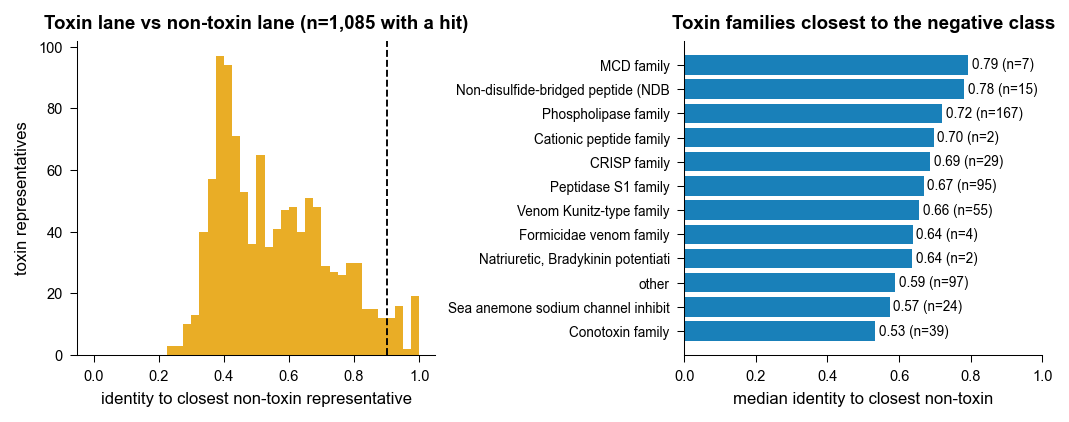

,n_with_hit,median_id,max_id,n_reps,pct_with_hit
family,,,,,
MCD family,7,0.793,0.965,62,11%
Non-disulfide-bridged peptide (NDBP) superfamily,15,0.782,1.000,30,50%
Phospholipase family,167,0.721,1.000,175,95%
Cationic peptide family,2,0.697,0.714,51,4%
CRISP family,29,0.687,0.994,30,97%
Peptidase S1 family,95,0.669,0.934,95,100%
Venom Kunitz-type family,55,0.657,1.000,56,98%
Formicidae venom family,4,0.638,0.730,36,11%
"Natriuretic, Bradykinin potentiating peptide family",2,0.636,0.657,71,3%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.7), layout="constrained")

ax = axes[0]
ax.hist(glob_best.fident, bins=np.arange(0, 1.02, .025), color=C_TOX, alpha=.85)
ax.axvline(DUP_IDENT, color="k", ls="--", lw=.9)
ax.set_xlabel("identity to closest non-toxin representative"); ax.set_ylabel("toxin representatives")
ax.set_title(f"Toxin lane vs non-toxin lane (n={len(glob_best):,} with a hit)")

# which toxin families sit closest to the negative class?
gb = glob_best.assign(family=glob_best["query"].map(fam_of))
byfam = (gb.groupby("family").agg(n_with_hit=("fident", "size"), median_id=("fident", "median"),
                                  max_id=("fident", "max")).join(
         pd.Series({f: sum(1 for i, x in fam_of.items() if x == f) for f in gb.family.unique()}, name="n_reps"))
         .assign(pct_with_hit=lambda d: d.n_with_hit / d.n_reps)
         .sort_values("median_id", ascending=False))
top = byfam.head(12).iloc[::-1]
ax = axes[1]
ax.barh(range(len(top)), top.median_id, color=C_NONTOX, alpha=.9)
ax.set_yticks(range(len(top))); ax.set_yticklabels([s[:34] for s in top.index], fontsize=6.5)
ax.set_xlabel("median identity to closest non-toxin"); ax.set_xlim(0, 1)
ax.set_title("Toxin families closest to the negative class")
for i, (v, n) in enumerate(zip(top.median_id, top.n_with_hit)):
    ax.text(v + .01, i, f"{v:.2f} (n={int(n)})", va="center", fontsize=6.5)
plt.show()

display(byfam.head(12).style.format({"median_id": "{:.3f}", "max_id": "{:.3f}", "pct_with_hit": "{:.0%}"})
        .set_caption("Toxin families whose members most resemble non-toxins"))

**Reading.** A large minority of toxin representatives have a detectable non-toxin homolog,
and a nontrivial number have a *near-duplicate* one. The families at the top of the right-hand
panel are precisely the ones the Discussion names as convergently recruited from physiological
scaffolds — now with numbers instead of assertion.

It is tempting to jump from here to "so a homology baseline must mislabel a third of the toxins",
but that does not follow: *having* a non-toxin homolog is not the same as having a non-toxin as
one's **nearest** neighbour. A toxin with a 50%-identical non-toxin relative and a 95%-identical
toxin relative is still labelled correctly by 1-NN. The quantity that actually bounds a
homology-transfer baseline is the second one, so measure it directly.

In [17]:
# Search every toxin representative against ALL representatives (both lanes), drop self-hits,
# and ask what its single best hit is. This is the quantity HBI/EAT-style transfer depends on.
nn = mmseqs_search(ftox, MM / "representatives" / "all.fasta", "tox_vs_all", s=7.5, max_seqs=50)
nn = nn[nn["query"] != nn["target"]]
# NB: pick the neighbour by BIT SCORE, not identity -- that is what a homology-transfer
# baseline (HBI) actually ranks on. best_hits() sorts by fident, so it is deliberately not used.
nn_best = (nn[nn["alncov"] >= DUP_COV]
           .sort_values("bits", ascending=False).drop_duplicates("query"))
nn_best = nn_best.assign(nn_family=nn_best["target"].map(fam_of),
                         nn_is_nontox=lambda d: d["target"].map(fam_of) == "nontox")

nn_fail = int(nn_best.nn_is_nontox.sum())
print(f"toxin representatives                                  : {n_tox_rep:,}")
print(f"  ...that merely HAVE a non-toxin homolog              : {len(glob_best):,} ({len(glob_best)/n_tox_rep:.1%})")
print(f"  ...whose NEAREST neighbour of all is a non-toxin      : {nn_fail:,} ({nn_fail/n_tox_rep:.1%})")
print(f"\nThe second number is the floor on 1-NN homology transfer: those toxins are labelled")
print(f"non-toxic by any method that copies its best hit's label, no matter how good the search is.")
sub = nn_best[nn_best.nn_is_nontox]
print(f"\nidentity to that non-toxin nearest neighbour:")
for t in (0.9, 0.7, 0.5, 0.3):
    print(f"  >= {t:.0%}: {int((sub.fident >= t).sum()):>4}")

  [cached] tox_vs_all


toxin representatives                                  : 3,416
  ...that merely HAVE a non-toxin homolog              : 1,085 (31.8%)
  ...whose NEAREST neighbour of all is a non-toxin      : 173 (5.1%)

The second number is the floor on 1-NN homology transfer: those toxins are labelled
non-toxic by any method that copies its best hit's label, no matter how good the search is.

identity to that non-toxin nearest neighbour:
  >= 90%:   46
  >= 70%:  107
  >= 50%:  148
  >= 30%:  169


**5.1% is the honest number**, and it is the one to quote — not the 32%. It is a hard floor: those
toxins are assigned a non-toxin label by *any* method that transfers its best hit's annotation,
however sensitive the search, because the nearest thing in sequence space genuinely is not a
toxin. A learned representation is not obliged to make the same call, since it can weigh features
the best-hit rule discards.

That is the defensible form of the argument for the ToxFam design: **the toxic/non-toxic boundary
does not coincide with the homology boundary**, so homology transfer has an irreducible error
floor that a learned model can get under. It is also why per-family clustering must not be
replaced by global clustering — global clustering would silently delete exactly these
informative pairs.

## 6. The cost of leanness: residual train↔test homology

Leanness is not free, and the manuscript already concedes the mechanism —
*"the identity ceiling is enforced only among the retained representatives, [so] this is
redundancy reduction rather than a strict homology-based partition."* Splits are drawn by
stratified random sampling **after** clustering, so nothing stops a test representative from
having a 89%-identical training neighbour.

Measure it directly.

In [18]:
split_series = reps["identifier"].map(split_of)
train_ids = set(reps.loc[split_series == "train", "identifier"])
test_ids  = set(reps.loc[split_series == "test",  "identifier"])
print(f"train {len(train_ids):,} | val {(split_series=='val').sum():,} | test {len(test_ids):,}")

ftrain, ftest = WORK / "rep_train.fasta", WORK / "rep_test.fasta"
if not (ftrain.exists() and ftest.exists()):
    with open(MM / "representatives" / "all.fasta") as src, open(ftrain, "w") as a, open(ftest, "w") as b:
        h = None
        for line in src:
            if line.startswith(">"):
                i = line[1:].strip().split()[0]
                h = a if i in train_ids else (b if i in test_ids else None)
            if h is not None:
                h.write(line)

# s=5.7 here rather than 7.5: this is the largest search in the notebook and the result is
# insensitive to it (checked at s=7.5 -- 254 vs 253 toxin reps >=70%, and identical counts at >=90%).
tt = mmseqs_search(ftest, ftrain, "test_vs_train", s=5.7, max_seqs=100)
tt_best = best_hits(tt, "query", min_cov=DUP_COV)
tt_best = tt_best.assign(family=tt_best["query"].map(fam_of))

def leak_table(sub, label, n_total):
    row = {"subset": label, "n": n_total, "no hit": n_total - len(sub)}
    for lo, hi in [(0.9, 1.01), (0.7, 0.9), (0.5, 0.7), (0.0, 0.5)]:
        row[f"{lo:.0%}-{hi if hi<=1 else 1:.0%}"] = int(((sub.fident >= lo) & (sub.fident < hi)).sum())
    return row

tox_test = {i for i in test_ids if fam_of.get(i) != "nontox"}
rows = [leak_table(tt_best, "all test reps", len(test_ids)),
        leak_table(tt_best[tt_best.family != "nontox"], "toxin test reps", len(tox_test)),
        leak_table(tt_best[tt_best.family == "nontox"], "non-toxin test reps", len(test_ids) - len(tox_test))]
display(pd.DataFrame(rows).set_index("subset").style.set_caption(
    "Best-hit identity from each TEST representative into the TRAINING set"))

tox_only = tt_best[tt_best.family != "nontox"]
print(f"\ntoxin test reps with a >=70% identical training neighbour: "
      f"{(tox_only.fident>=0.7).sum()} / {len(tox_test)} = {(tox_only.fident>=0.7).sum()/len(tox_test):.1%}")
print(f"toxin test reps with a >=90% identical training neighbour: "
      f"{(tox_only.fident>=0.9).sum()} / {len(tox_test)} = {(tox_only.fident>=0.9).sum()/len(tox_test):.1%}")

train 45,621 | val 9,779 | test 9,779
  [cached] test_vs_train


,n,no hit,90%-100%,70%-90%,50%-70%,0%-50%
subset,,,,,,
all test reps,9779,1866,30,4777,1924,1182
toxin test reps,515,114,8,245,102,46
non-toxin test reps,9264,1752,22,4532,1822,1136



toxin test reps with a >=70% identical training neighbour: 253 / 515 = 49.1%
toxin test reps with a >=90% identical training neighbour: 8 / 515 = 1.6%


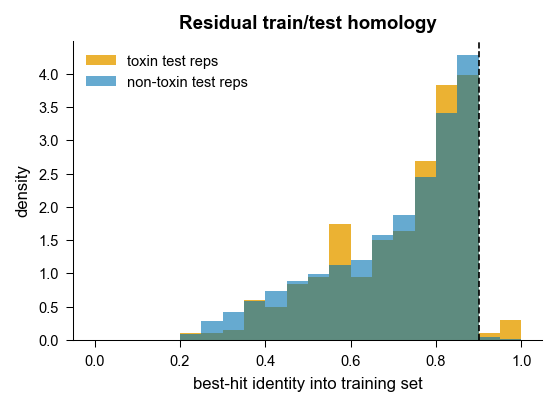

In [19]:
fig, ax = plt.subplots(figsize=(3.6, 2.6), layout="constrained")
bins = np.arange(0, 1.02, .05)
ax.hist(tt_best[tt_best.family != "nontox"].fident, bins=bins, color=C_TOX, alpha=.8,
        density=True, label="toxin test reps")
ax.hist(tt_best[tt_best.family == "nontox"].fident, bins=bins, color=C_NONTOX, alpha=.6,
        density=True, label="non-toxin test reps")
ax.axvline(0.9, color="k", ls="--", lw=.8)
ax.set_xlabel("best-hit identity into training set"); ax.set_ylabel("density")
ax.set_title("Residual train/test homology"); ax.legend()
plt.show()

### 6.1 Where does the residual ≥90% leakage come from?

Note the shape of the table above: very few test representatives have a ≥90% identical
training neighbour, but many have a 50–90% one.

The natural expectation is that the few remaining ≥90% pairs must be **cross-family** — two
representatives of the same family passed through the same clustering run, so they "should"
already be below 90% of each other, whereas per-family clustering can never see a
cross-family pair (§3). Worth testing rather than assuming.

In [20]:
hi = tt_best[tt_best.fident >= DUP_IDENT].assign(
    test_family=lambda d: d["query"].map(fam_of), train_family=lambda d: d["target"].map(fam_of))
hi["cross_family"] = hi.test_family != hi.train_family

print(f"test reps with a >={DUP_IDENT:.0%} identical training neighbour: {len(hi)}")
if len(hi):
    print(f"  cross-family pairs : {hi.cross_family.sum()} ({hi.cross_family.mean():.0%})")
    print(f"  same-family pairs  : {(~hi.cross_family).sum()}")
    print(f"\n  of the cross-family pairs, toxin<->non-toxin: "
          f"{((hi.test_family == 'nontox') != (hi.train_family == 'nontox')).sum()}")
    display(hi[hi.cross_family][["query", "target", "fident", "alncov", "test_family", "train_family"]]
            .head(10).style.format({"fident": "{:.3f}", "alncov": "{:.2f}"}).hide(axis="index")
            .set_caption("Cross-family near-duplicates spanning train and test"))

test reps with a >=90% identical training neighbour: 30
  cross-family pairs : 12 (40%)
  same-family pairs  : 18

  of the cross-family pairs, toxin<->non-toxin: 12


query,target,fident,alncov,test_family,train_family
P00598,P00597,1.000,0.98,Phospholipase family,nontox
P0DPU1,P0DPV2,0.994,1.00,CRISP family,nontox
Q6ITB9,Q6ITB4,0.983,1.00,Venom Kunitz-type family,nontox
Q6ITB1,B5L5R0,0.983,1.00,Venom Kunitz-type family,nontox
P83082,Q58T40,0.976,1.00,other,nontox
P0DXZ6,I7GQA7,0.949,1.00,Phospholipase family,nontox
A8E2V9,Q92152,0.932,0.98,nontox,Phospholipase family
P0DJ46,P0DJ48,0.932,1.00,nontox,Venom Kunitz-type family
P20249,Q6H3D0,0.925,0.99,nontox,Phospholipase family
P0DPT0,P0DMB4,0.923,0.96,nontox,other


**The expectation was half wrong, and the half that failed is the informative one.**

The cross-family pairs behave exactly as §3 predicts: *every one of them* is a
toxin↔non-toxin pair, i.e. precisely the pairs per-family clustering is structurally
incapable of removing. That is decision 2's blind spot showing up at the train/test boundary,
not a new problem.

But a majority of the ≥90% pairs are **same-family** — which the 90% clustering was supposed
to have prevented. It did not, because `easy_cluster` is a greedy set-cover, not a complete-linkage
partition: it guarantees each member is within the threshold *of its own representative*, not
that two representatives of different clusters are below the threshold *of each other*.
Cluster-time coverage (`--cov-mode 0`, bidirectional) also differs from the coverage measured
here (`alnlen / max(qlen, tlen)`), so borderline pairs fall on opposite sides of the two tests.

Neither effect is large — 30 of 9,779 test representatives — but the second one means **the
manuscript cannot claim that no train/test pair exceeds 90% identity.** It should claim what
is true: that no member exceeds 90% identity to its own cluster representative.

**Verdict.** This is the honest cost of decision 1, and it should be reported rather than
discovered by a reviewer. Near-duplicate train/test pairs are rare; what remains is a broad
band of 50–90% train/test similarity — real homology, not duplication. The consequence for
the manuscript is one of framing: headline family-classification metrics are **not** a
measure of remote-homology generalisation — they measure performance on a realistic,
redundancy-reduced but homology-rich distribution.

That framing is defensible, and it is the right one for this application: a curator triaging a
new Swiss-Prot entry genuinely does encounter proteins similar to known toxins, so a
homology-partitioned benchmark would understate real-world utility. But the manuscript should
(a) state the identity distribution above, and (b) lean on the two evaluation sets that *are*
distribution-shifted — `non_metazoan` and `unreviewed` — as the generalisation evidence, since
neither shares the training distribution. The identity-stratified Table S3 already gestures at
this; the numbers here make it explicit.

## 7. Decision 6 — why trim signal peptides at all?

Before clustering, the pipeline runs SignalP6 and trims any predicted signal peptide with
cleavage probability >0.8 from the N-terminus (`preprocessing.py:229-280`, threshold at
`:144`). The manuscript justifies this in a single clause — *"so that all downstream
representations are built from mature sequences"* — which restates the action rather than
giving a reason, and never defends the 0.8 cutoff.

There are three independent reasons to trim, plus the question of the cutoff itself:

- **7.1** the signal peptide is a far larger share of a toxin than of a non-toxin;
- **7.2** without trimming the data mixes two sequence frames *within* families — the reason
  the trimming was introduced;
- **7.3** signal-peptide presence is additionally a toxicity shortcut *between* classes;
- **7.4** whether p>0.8 is a defensible operating point at all.

In [21]:
import hashlib as _hl

# The pipeline caches SP6 results per sequence, keyed by MD5 of the ORIGINAL sequence
# (preprocessing.py:90-92). Reuse that cache rather than re-running SignalP6: it is the exact
# artifact the released split was built from.
_cache = json.loads((INTER / "sp6" / "sp6_cache.json").read_text())
_h = lambda s: _hl.md5(s.encode()).hexdigest()

def with_sp(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["mature"] = [_cache.get(_h(s)) for s in d["Sequence"]]
    d["trimmed"] = d["mature"].notna()             # SP6 reported a cleavage site at p > 0.8
    d["full_len"] = d["Sequence"].str.len()
    d["sp_len"] = [len(s) - len(m) if m is not None else 0
                   for s, m in zip(d["Sequence"], d["mature"])]
    d["sp_frac"] = d["sp_len"] / d["full_len"]
    d["uni_sp"] = d["Signal peptide"].notna()      # UniProt's curated SIGNAL annotation
    return d

tox_sp, nt_sp = with_sp(tox), with_sp(nt)
print(f"SP6 cache: {len(_cache):,} sequences, {sum(v is not None for v in _cache.values()):,} with a cleavage site\n")
for d, name in [(tox_sp, "toxins"), (nt_sp, "non-toxins")]:
    print(f"  {name:<11} {d.trimmed.sum():>6,} / {len(d):>6,} trimmed = {d.trimmed.mean():.1%}")

SP6 cache: 100,217 sequences, 20,644 with a cleavage site

  toxins       3,785 /  5,567 trimmed = 68.0%
  non-toxins  17,241 / 98,850 trimmed = 17.4%


### 7.1 A signal peptide is a quarter of a toxin and a rounding error in a non-toxin

Signal peptides are roughly constant in length (~20-25 aa) regardless of the protein carrying
them. Toxins are short (median 80 aa) and non-toxins are not (median 368 aa), so the *same*
absolute prefix occupies very different fractions of the two classes.

signal-peptide length (aa)      : toxins median 21 | non-toxins median 22
as a FRACTION of the sequence   : toxins median 24.4% | non-toxins median 7.1%
sequences where the SP is >20%  : toxins 64% | non-toxins 13%


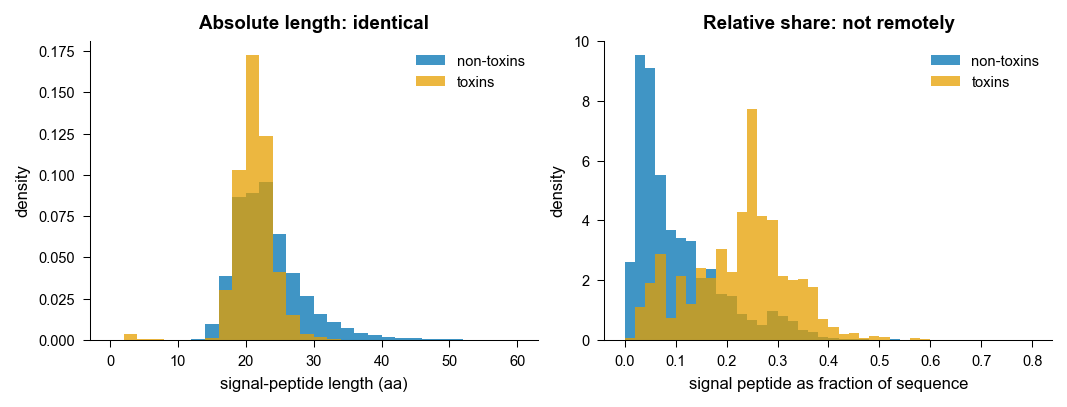

In [22]:
t_sp, n_sp = tox_sp[tox_sp.trimmed], nt_sp[nt_sp.trimmed]
print(f"signal-peptide length (aa)      : toxins median {t_sp.sp_len.median():.0f} | non-toxins median {n_sp.sp_len.median():.0f}")
print(f"as a FRACTION of the sequence   : toxins median {t_sp.sp_frac.median():.1%} | non-toxins median {n_sp.sp_frac.median():.1%}")
print(f"sequences where the SP is >20%  : toxins {(t_sp.sp_frac > .2).mean():.0%} | non-toxins {(n_sp.sp_frac > .2).mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), layout="constrained")
ax = axes[0]
bins = np.arange(0, 61, 2)
ax.hist(n_sp.sp_len, bins=bins, color=C_NONTOX, alpha=.75, density=True, label="non-toxins")
ax.hist(t_sp.sp_len, bins=bins, color=C_TOX, alpha=.75, density=True, label="toxins")
ax.set_xlabel("signal-peptide length (aa)"); ax.set_ylabel("density")
ax.set_title("Absolute length: identical"); ax.legend()

ax = axes[1]
bins = np.arange(0, .81, .02)
ax.hist(n_sp.sp_frac, bins=bins, color=C_NONTOX, alpha=.75, density=True, label="non-toxins")
ax.hist(t_sp.sp_frac, bins=bins, color=C_TOX, alpha=.75, density=True, label="toxins")
ax.set_xlabel("signal peptide as fraction of sequence"); ax.set_ylabel("density")
ax.set_title("Relative share: not remotely"); ax.legend()
plt.show()

This alone justifies trimming for a per-protein embedding model. ProtT5 pools over the whole
sequence, so leaving the signal peptide in place means roughly **a quarter of the average
toxin's representation encodes a secretion tag** — against ~7% for the average non-toxin. The
distortion is not merely present, it is *class-dependent*, which is exactly the kind of
asymmetry a classifier will happily exploit. §7.2 shows what it would exploit it for.

### 7.2 The reason we actually trimmed: otherwise the data mixes two sequence frames

SignalP6 fires on 68% of toxins — which means that *without* trimming, the training set would
contain both kinds of sequence side by side: some proteins carrying their N-terminal signal
peptide, others (cytosolic ones, or entries already deposited as mature chains) not.

That inconsistency is not spread evenly across the label space, and it is not a between-class
effect like §7.3 — it happens **inside individual families**, where two members of the same
class are represented in two different frames. Measure how widespread that is.

toxin families with >=10 members : 45
  near-homogeneous (<10% or >90% trimmed) : 15
  MIXED (10%-90% trimmed)                 : 30  -- 5,072 sequences = 91% of all family-labelled toxins


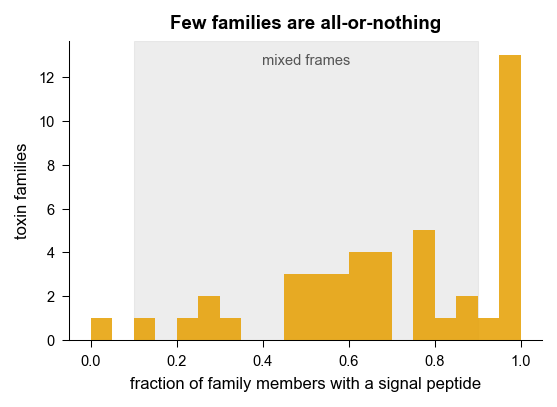

,n,trim_rate
family,,
Conotoxin family,996,78%
Neurotoxin family,962,78%
Three-finger toxin family,485,55%
other,358,63%
Long (4 C-C) scorpion toxin superfamily,341,62%
Phospholipase family,327,66%
Short scorpion toxin superfamily,266,51%
Venom metalloproteinase (M12B) family,188,59%
Peptidase S1 family,156,82%


In [23]:
# Per-family trim rate, on the pipeline's own normalized family labels.
tox_fam = normalize_protein_families(tox_sp.copy())["Protein families"]
fam_sp = (tox_sp.assign(family=tox_fam).groupby("family")["trimmed"]
          .agg(n="size", trim_rate="mean").query("n >= 10").sort_values("trim_rate"))

MIX_LO, MIX_HI = 0.10, 0.90
fam_sp["mixed"] = fam_sp.trim_rate.between(MIX_LO, MIX_HI)
mixed = fam_sp[fam_sp.mixed]

print(f"toxin families with >=10 members : {len(fam_sp)}")
print(f"  near-homogeneous (<{MIX_LO:.0%} or >{MIX_HI:.0%} trimmed) : {(~fam_sp.mixed).sum()}")
print(f"  MIXED ({MIX_LO:.0%}-{MIX_HI:.0%} trimmed)                 : {len(mixed)}"
      f"  -- {mixed.n.sum():,} sequences = {mixed.n.sum()/fam_sp.n.sum():.0%} of all family-labelled toxins")

fig, ax = plt.subplots(figsize=(3.6, 2.6), layout="constrained")
ax.hist(fam_sp.trim_rate, bins=np.arange(0, 1.05, .05), color=C_TOX, alpha=.85)
ax.axvspan(MIX_LO, MIX_HI, color=C_GREY, alpha=.25, zorder=0)
ax.annotate("mixed frames", ((MIX_LO + MIX_HI) / 2, ax.get_ylim()[1] * .92), ha="center", fontsize=7, color="#555")
ax.set_xlabel("fraction of family members with a signal peptide"); ax.set_ylabel("toxin families")
ax.set_title("Few families are all-or-nothing")
plt.show()

display(fam_sp.loc[fam_sp.mixed, ["n", "trim_rate"]].sort_values("n", ascending=False).head(10)
        .style.format({"trim_rate": "{:.0%}"}).set_caption("Largest mixed families -- both frames present in the same class"))

So the heterogeneity is the normal case, not an edge case. The question is whether it does any
harm — and the answer turns out to depend entirely on *which* downstream step you ask about.

Start with alignment. Within a mixed family, take the members that carry a signal peptide and
align them against the members that do not, **before** and **after** trimming.

In [24]:
mixed_csv = WORK / "sp_frames_v2.csv"
if mixed_csv.exists():
    frames = pd.read_csv(mixed_csv)
    print(f"[cached] {mixed_csv.name}")
else:
    recs = []
    t0 = time.time()
    for fam in mixed.index:
        g = tox_sp[tox_fam == fam]
        has, lacks = g[g.trimmed], g[~g.trimmed]
        if len(has) < 5 or len(lacks) < 5:
            continue
        fasta_of(lacks, WORK / "sp_target.fasta")                       # never trimmed either way
        for mode, col in [("untrimmed", "Sequence"), ("trimmed", "mature")]:
            q = has.rename(columns={"Entry": "identifier"})[["identifier", col]] \
                   .rename(columns={col: "Sequence"})
            fasta_of(q, WORK / "sp_query.fasta")
            hits = mmseqs_search(WORK / "sp_query.fasta", WORK / "sp_target.fasta",
                                 "sp_frames_tmp", force=True, quiet=True)
            best = hits.sort_values("bits", ascending=False).drop_duplicates("query")
            recs.append({"family": fam, "mode": mode, "n_sp": len(has), "n_nosp": len(lacks),
                         "median_identity": best["fident"].median(),
                         "median_coverage": best["alncov"].median(),
                         "median_alnlen": best["alnlen"].median(),
                         "median_bits": best["bits"].median()})
    frames = pd.DataFrame(recs)
    frames.to_csv(mixed_csv, index=False)
    print(f"  {len(frames)//2} mixed families compared in {time.time()-t0:.0f}s")

piv = frames.pivot(index="family", columns="mode",
                   values=["median_identity", "median_coverage", "median_alnlen", "median_bits"])
delta = pd.DataFrame({
    "n_sp": frames.groupby("family").n_sp.first(),
    "cov_untrimmed": piv[("median_coverage", "untrimmed")], "cov_trimmed": piv[("median_coverage", "trimmed")],
    "id_untrimmed": piv[("median_identity", "untrimmed")],  "id_trimmed": piv[("median_identity", "trimmed")],
    "aln_untrimmed": piv[("median_alnlen", "untrimmed")],   "aln_trimmed": piv[("median_alnlen", "trimmed")],
    "bits_untrimmed": piv[("median_bits", "untrimmed")],    "bits_trimmed": piv[("median_bits", "trimmed")],
}).assign(cov_gain=lambda d: d.cov_trimmed - d.cov_untrimmed,
          id_gain=lambda d: d.id_trimmed - d.id_untrimmed,
          aln_gain=lambda d: d.aln_trimmed - d.aln_untrimmed,
          bits_gain=lambda d: d.bits_trimmed - d.bits_untrimmed).sort_values("cov_gain", ascending=False)

print(f"\nacross {len(delta)} mixed families, aligning SP-bearing members to SP-less members of the SAME family:")
print(f"  median alignment COVERAGE   {delta.cov_untrimmed.median():.2f} -> {delta.cov_trimmed.median():.2f} "
      f"({delta.cov_gain.median():+.2f})   <- moves")
print(f"  median sequence IDENTITY    {delta.id_untrimmed.median():.3f} -> {delta.id_trimmed.median():.3f} "
      f"({delta.id_gain.median():+.3f})   <- does not")
print(f"  median ALIGNMENT LENGTH     {delta.aln_untrimmed.median():.0f} -> {delta.aln_trimmed.median():.0f} "
      f"({delta.aln_gain.median():+.0f})   <- does not")
print(f"  median BIT SCORE            {delta.bits_untrimmed.median():.0f} -> {delta.bits_trimmed.median():.0f} "
      f"({delta.bits_gain.median():+.0f})   <- does not")
print(f"\n  families where the alignment itself changed at all: "
      f"{int((delta.aln_gain != 0).sum())} / {len(delta)}")
display(delta[["n_sp", "cov_untrimmed", "cov_trimmed", "aln_untrimmed", "aln_trimmed",
               "bits_untrimmed", "bits_trimmed"]].head(8)
        .style.format({"cov_untrimmed": "{:.2f}", "cov_trimmed": "{:.2f}", "aln_untrimmed": "{:.0f}",
                       "aln_trimmed": "{:.0f}", "bits_untrimmed": "{:.0f}", "bits_trimmed": "{:.0f}"})
        .set_caption("Trimming changes the coverage denominator, not the alignment"))

[cached] sp_frames_v2.csv

across 24 mixed families, aligning SP-bearing members to SP-less members of the SAME family:
  median alignment COVERAGE   0.56 -> 0.77 (+0.15)   <- moves
  median sequence IDENTITY    0.731 -> 0.735 (+0.000)   <- does not
  median ALIGNMENT LENGTH     47 -> 47 (+0)   <- does not
  median BIT SCORE            79 -> 79 (+0)   <- does not

  families where the alignment itself changed at all: 5 / 24


,n_sp,cov_untrimmed,cov_trimmed,aln_untrimmed,aln_trimmed,bits_untrimmed,bits_trimmed
family,,,,,,,
Short scorpion toxin superfamily,135,0.56,0.92,33,34,59,58
Crotamine-myotoxin family,7,0.65,0.98,42,42,108,108
Three-finger toxin family,269,0.74,1.00,62,62,121,121
Long (4 C-C) scorpion toxin superfamily,213,0.76,0.97,64,64,126,126
Sea anemone type 3 (BDS) potassium channel toxin family,21,0.55,0.75,43,43,99,99
Sea anemone sodium channel inhibitory toxin family,39,0.57,0.77,47,47,73,73
MCD family,21,0.23,0.42,14,14,27,27
Venom Kunitz-type family,64,0.69,0.88,57,57,92,92


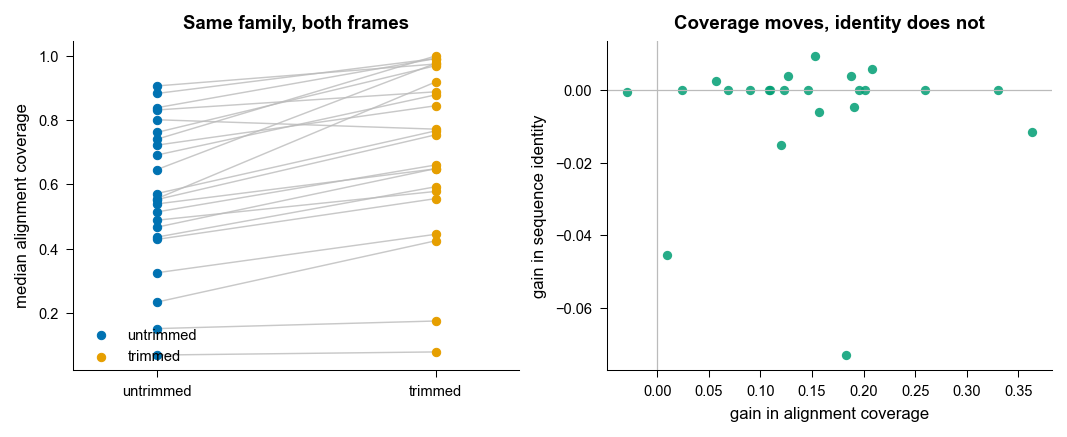

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), layout="constrained")

ax = axes[0]
for i, (fam, r) in enumerate(delta.iterrows()):
    ax.plot([0, 1], [r.cov_untrimmed, r.cov_trimmed], "-", color=C_GREY, lw=.7, alpha=.8, zorder=1)
ax.scatter(np.zeros(len(delta)), delta.cov_untrimmed, s=16, color=C_NONTOX, zorder=2, label="untrimmed")
ax.scatter(np.ones(len(delta)), delta.cov_trimmed, s=16, color=C_TOX, zorder=2, label="trimmed")
ax.set_xticks([0, 1]); ax.set_xticklabels(["untrimmed", "trimmed"]); ax.set_xlim(-.3, 1.3)
ax.set_ylabel("median alignment coverage"); ax.set_title("Same family, both frames")
ax.legend(loc="lower left", bbox_to_anchor=(0, -0.02))

ax = axes[1]
ax.scatter(delta.cov_gain, delta.id_gain, s=20, color=C_ACCENT, alpha=.85, linewidths=0)
ax.axhline(0, color=C_GREY, lw=.6); ax.axvline(0, color=C_GREY, lw=.6)
ax.set_xlabel("gain in alignment coverage"); ax.set_ylabel("gain in sequence identity")
ax.set_title("Coverage moves, identity does not")
plt.show()

**Read this carefully, because it says something sharper than "trimming helps".** Identity,
alignment length and bit score are *identical* before and after trimming — the alignment does
not change at all. Only coverage moves, and it moves because coverage is
`alnlen / max(qlen, tlen)` and trimming shrinks the denominator.

That is not a weaker result; it is a cleaner one. **It proves the signal peptide is inert to
alignment.** MMseqs2 finds exactly the same alignment, with exactly the same score, whether the
signal peptide is present or not — because those ~20 residues have no counterpart in the
homolog to align to. They are not misleading the aligner; they are invisible to it.

Which raises the obvious question: if alignment ignores the signal peptide, does the mixed
frame harm anything at all? Check the one alignment-based step in the pipeline that *is*
coverage-sensitive — `easy_cluster` applies a coverage threshold, so in principle a precursor
and a mature form could fail it and be split into separate clusters.

In [26]:
clust_csv = WORK / "sp_clustering.csv"
if clust_csv.exists():
    clust = pd.read_csv(clust_csv, index_col=0)
    print(f"[cached] {clust_csv.name}")
else:
    tox_all = tox_sp.assign(family=tox_fam)
    tox_all["seq_trimmed"] = [m if m is not None else s
                              for s, m in zip(tox_all["Sequence"], tox_all["mature"])]
    recs = {}
    for fam in mixed.sort_values("n", ascending=False).head(8).index:
        g = tox_all[tox_all.family == fam]
        n_rep = {}
        for mode, col in [("untrimmed", "Sequence"), ("trimmed", "seq_trimmed")]:
            q = g.rename(columns={"Entry": "identifier"})[["identifier", col]].rename(columns={col: "Sequence"})
            fasta_of(q, WORK / "clust_in.fasta")
            pre = WORK / f"clust_{mode}"
            with contextlib.redirect_stdout(io.StringIO()):
                easy_cluster(fasta_files=str(WORK / "clust_in.fasta"), cluster_prefix=str(pre),
                             tmp_dir=str(WORK / "clust_tmp"), min_seq_id=0.9)
            n_rep[mode] = sum(1 for l in open(f"{pre}_rep_seq.fasta") if l.startswith(">"))
        recs[fam] = {"n": len(g), **n_rep}
    clust = pd.DataFrame(recs).T
    clust.to_csv(clust_csv)

clust["delta"] = clust["trimmed"] - clust["untrimmed"]
display(clust.style.set_caption("Representatives at min_seq_id=0.9, clustering untrimmed vs trimmed sequences"))
print(f"total over these {len(clust)} families: {int(clust.untrimmed.sum()):,} reps untrimmed -> "
      f"{int(clust.trimmed.sum()):,} trimmed ({int(clust.delta.sum()):+d})")
print("the sign varies by family -- clustering is essentially unaffected by the mixed frame.")

[cached] sp_clustering.csv


,n,untrimmed,trimmed,delta
Conotoxin family,996,731,753,22
Neurotoxin family,962,394,399,5
Three-finger toxin family,485,258,240,-18
other,358,281,284,3
Long (4 C-C) scorpion toxin superfamily,341,220,190,-30
Phospholipase family,327,173,175,2
Short scorpion toxin superfamily,266,197,185,-12
Venom metalloproteinase (M12B) family,188,122,123,1


total over these 8 families: 2,376 reps untrimmed -> 2,349 trimmed (-27)
the sign varies by family -- clustering is essentially unaffected by the mixed frame.


So clustering is a wash too. The mixed frame is invisible to **every alignment-based step in
the pipeline**: the MMseqs2 clustering of §2, and the HBI baseline, which ranks hits by bit
score — a quantity we just showed is unchanged.

**That is precisely what isolates the real reason for trimming.** ProtT5 has no alignment step.
It pools a representation over *every residue it is given*, so it cannot skip a prefix the way
an aligner does. Two members of one family are then embedded from inputs differing by a
systematic ~20-residue block present in one and absent in the other — and per §7.1 that block
is roughly a quarter of a median toxin. Trimming puts every sequence in the same frame, so
within-family variation in the embedding reflects biology rather than whether UniProt's entry
happened to begin at the precursor or the mature chain.

The honest form of the argument is therefore: **the mixed frame matters *because* the model is
embedding-based.** Had ToxFam been a pure homology method, trimming would have been optional.
This also predicts that the EAT baseline (1-NN in ProtT5 space) is sensitive to trimming while
HBI (MMseqs) is not — a prediction this notebook does not test, since it would require
re-embedding both variants.

### 7.3 A second, independent reason: signal-peptide presence is itself a toxicity signal

68% of toxins carry a detectable signal peptide against 17% of non-toxins — the manuscript
notes this and attributes it to biology (*"the strong enrichment of secreted proteins among
toxins"*), which is correct. But it stops there, and the consequence is the whole point:
**an untrimmed model could learn to detect secretion and score well on toxicity.**

This is a *between-class* effect, independent of the within-family frame mismatch in §7.2 —
and it survives trimming's main purpose rather than motivating it. Quantify how good the
shortcut would be, by scoring "has a signal peptide" directly as a binary toxicity classifier.

"has a signal peptide" used ALONE as a toxic/non-toxic classifier:

  MCC            0.283
  precision      0.180
  recall         0.680
  odds ratio     10.1x   (odds of carrying an SP, toxin vs non-toxin)

  P(toxin)                     = 5.33%  (base rate)
  P(toxin | has signal peptide) = 18.00%  (3.4x lift)


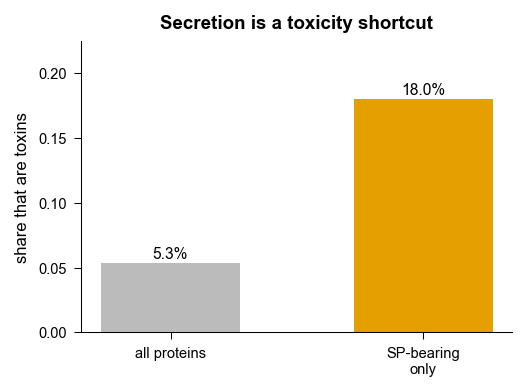

In [27]:
from sklearn.metrics import matthews_corrcoef, precision_score, recall_score

y_true = np.r_[np.ones(len(tox_sp)), np.zeros(len(nt_sp))]
y_pred = np.r_[tox_sp.trimmed.values, nt_sp.trimmed.values].astype(int)

tox_yes, tox_no = tox_sp.trimmed.sum(), (~tox_sp.trimmed).sum()
nt_yes, nt_no   = nt_sp.trimmed.sum(), (~nt_sp.trimmed).sum()
sp_or  = (tox_yes / tox_no) / (nt_yes / nt_no)
sp_mcc = matthews_corrcoef(y_true, y_pred)
sp_base, sp_lift = len(tox_sp) / (len(tox_sp) + len(nt_sp)), tox_yes / (tox_yes + nt_yes)

print('"has a signal peptide" used ALONE as a toxic/non-toxic classifier:\n')
print(f"  MCC            {sp_mcc:.3f}")
print(f"  precision      {precision_score(y_true, y_pred):.3f}")
print(f"  recall         {recall_score(y_true, y_pred):.3f}")
print(f"  odds ratio     {sp_or:.1f}x   (odds of carrying an SP, toxin vs non-toxin)")
print(f"\n  P(toxin)                     = {sp_base:.2%}  (base rate)")
print(f"  P(toxin | has signal peptide) = {sp_lift:.2%}  ({sp_lift/sp_base:.1f}x lift)")

fig, ax = plt.subplots(figsize=(3.4, 2.5), layout="constrained")
ax.bar(["all proteins", "SP-bearing\nonly"], [sp_base, sp_lift], color=[C_GREY, C_TOX], width=.55)
for i, v in enumerate([sp_base, sp_lift]):
    ax.text(i, v + .004, f"{v:.1%}", ha="center", fontsize=7.5)
ax.set_ylabel("share that are toxins"); ax.set_ylim(0, sp_lift * 1.25)
ax.set_title("Secretion is a toxicity shortcut")
plt.show()

**This is the argument the manuscript should be making.** A single bit — does SignalP6 fire? —
recovers 68% of all toxins and more than triples the prevalence of toxins in the proteins it
selects. It is a genuinely predictive feature, and a genuinely misleading one: it tracks
*secretion*, not *toxicity*. Most secreted proteins are not toxins (the same bit has 18%
precision), and a model leaning on it would fail exactly where it matters most — on secreted
non-toxins such as the physiological phospholipases of §4, every one of which carries a signal
peptide too.

Trimming removes the shortcut before the model can see it. The N-terminal residues that
distinguish "secreted" from "cytosolic" are deleted for *both* classes, so the classifier is
forced to discriminate on the mature sequence — the part that actually determines whether the
protein is a toxin. This also makes the binary head's `p_toxic` interpretable as a statement
about the mature protein rather than about its trafficking signal.

### 7.4 Is p>0.8 defensible? Check SignalP6 against UniProt's curated annotation

The 0.8 cutoff is stated without justification. It is checkable: the raw TSVs carry UniProt's
own curated `SIGNAL` feature, which is independent of SignalP6 and can serve as a reference
standard — with the caveat that many UniProt signal-peptide annotations are themselves
sequence-analysis inferences (`ECO:0000255`) rather than experimental.

In [28]:
rows = []
for d, name in [(tox_sp, "toxins"), (nt_sp, "non-toxins")]:
    tp = int((d.trimmed & d.uni_sp).sum());  fp = int((d.trimmed & ~d.uni_sp).sum())
    fn = int((~d.trimmed & d.uni_sp).sum()); tn = int((~d.trimmed & ~d.uni_sp).sum())
    rows.append({"set": name, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                 "precision": tp / (tp + fp), "recall": tp / (tp + fn),
                 "agreement": (tp + tn) / len(d)})
agree = pd.DataFrame(rows).set_index("set")
display(agree.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "agreement": "{:.3f}"})
        .set_caption("SignalP6 (p > 0.8) vs UniProt's curated SIGNAL annotation"))

# where both agree a signal peptide exists, does SP6 cut in the same place?
uni_len = tox_sp["Signal peptide"].str.extract(r"SIGNAL 1\.\.(\d+)")[0].astype(float)
both = tox_sp[tox_sp.trimmed & uni_len.notna()]
cleave_delta = both.sp_len.values - uni_len.loc[both.index].values
cleave_exact, cleave_2 = float((cleave_delta == 0).mean()), float((np.abs(cleave_delta) <= 2).mean())
print(f"\ncleavage-site agreement on the {len(both):,} toxins where both call a signal peptide:")
print(f"  exact match  {cleave_exact:.1%}")
print(f"  within +/-2  {cleave_2:.1%}")
print(f"\nSP6 recall against curation is lower on non-toxins ({agree.loc['non-toxins','recall']:.1%}) "
      f"than on toxins ({agree.loc['toxins','recall']:.1%}):")
print(f"  {int(agree.loc['non-toxins','FN']):,} curated non-toxin signal peptides are left untrimmed at p > 0.8.")

,TP,FP,FN,TN,precision,recall,agreement
set,,,,,,,
toxins,3748,37,45,1737,0.990,0.988,0.985
non-toxins,16941,300,1619,79990,0.983,0.913,0.981



cleavage-site agreement on the 3,748 toxins where both call a signal peptide:
  exact match  86.0%
  within +/-2  94.2%

SP6 recall against curation is lower on non-toxins (91.3%) than on toxins (98.8%):
  1,619 curated non-toxin signal peptides are left untrimmed at p > 0.8.


**Verdict on decision 6.** Trimming is well justified — better than the manuscript claims — and
the threshold is sound but should be reported with its one asymmetry.

- The operating point is conservative and accurate: at p>0.8 SignalP6 agrees with UniProt
  curation on ~98% of proteins in both lanes, at ~99% precision, and lands the exact cleavage
  residue in the large majority of cases. This is not an arbitrary cutoff; it is a
  high-precision one, and 0.8 can be defended as such rather than merely stated.
- The stated rationale is the weakest available one. *"So that representations are built from
  mature sequences"* is circular. Three real reasons sit behind it, and the manuscript makes
  none of them: **§7.2**, the design reason — 68% trimming means the data would otherwise carry
  both precursor and mature frames *within the same family*, and while an aligner skips the
  signal peptide entirely (identical alignment length and bit score either way, clustering a
  wash), a pooled ProtT5 embedding cannot skip it; **§7.1**, that unskippable block is ~a quarter
  of a typical toxin, so mixed frames distort the toxin class far more than the non-toxin class;
  and **§7.3**, signal-peptide presence is additionally a 10x-odds toxicity shortcut tracking
  secretion rather than toxicity. Note that §7.2 is a reason specific to embedding-based models,
  not a general claim that trimming improves sequence similarity.
- **The one thing to disclose:** recall against curation is lower for non-toxins than for
  toxins, so the conservative threshold leaves a few thousand curated non-toxin signal
  peptides in place while removing nearly all toxin ones. Trimming therefore does not fully
  equalise the two classes — it shrinks the confound rather than eliminating it, and the
  residue happens to run in the direction that flatters the model. Worth one sentence.

## 8. Summary — decision → evidence → verdict

Numbers are filled in from the cells above so this table cannot drift from the analysis.

In [29]:
S = dict(
    tox_raw=len(tox_raw), nt_raw=len(nt_raw), tox=len(tox), nt=len(nt), cutoff=cutoff,
    reps=len(reps), tox_reps=n_tox_rep,
    red_tox=1 - tox_s.clusters.sum() / tox_s.members.sum(),
    red_nt=1 - nt_s.clusters.sum() / nt_s.members.sum(),
    conc=top5.removed.sum() / tox_s.removed.sum(), zero=len(zero),
    lo_thr=summary.iloc[0].threshold, lo_reps=int(summary.iloc[0].toxin_reps),
    lo_keep=int(summary.iloc[0].families_kept), hi_keep=int(summary[summary.threshold==0.9].iloc[0].families_kept),
    shared=len(shared), tox_pla=len(tox_pla), nt_pla=len(nt_pla), twins=len(twins),
    glob_hit=len(glob_best), glob_90=(glob_best.fident >= .9).sum(),
    leak70=(tox_only.fident >= .7).sum(), leak90=(tox_only.fident >= .9).sum(), n_tox_test=len(tox_test),
    hi_pairs=len(hi), hi_cross=int(hi.cross_family.sum()), hi_same=int((~hi.cross_family).sum()),
    nn_fail=nn_fail,
    pla_hit=len(pla_best), twins_rep=len(both_rep), twins_diff=diff_split, twins_tt=len(cross),
    n_fams=len(tox_s), tox_in_shared=shared.toxins.sum() / len(tox),
    nt_nofam=int(nt['Protein families'].isna().sum()),
    sp_tox=float(tox_sp.trimmed.mean()), sp_nt=float(nt_sp.trimmed.mean()),
    sp_frac_tox=float(t_sp.sp_frac.median()), sp_frac_nt=float(n_sp.sp_frac.median()),
    sp_mcc=float(sp_mcc), sp_or=float(sp_or), sp_base=float(sp_base), sp_lift=float(sp_lift),
    sp_agree_tox=float(agree.loc['toxins', 'agreement']),
    sp_prec_tox=float(agree.loc['toxins', 'precision']),
    sp_rec_tox=float(agree.loc['toxins', 'recall']),
    sp_rec_nt=float(agree.loc['non-toxins', 'recall']),
    sp_fn_nt=int(agree.loc['non-toxins', 'FN']),
    cleave_exact=cleave_exact, cleave_2=cleave_2,
    fam_mixed=int(fam_sp.mixed.sum()), fam_total=int(len(fam_sp)),
    mixed_share=float(mixed.n.sum() / fam_sp.n.sum()),
    cov_before=float(delta.cov_untrimmed.median()), cov_after=float(delta.cov_trimmed.median()),
    id_shift=float(delta.id_gain.median()), n_mixed_cmp=int(len(delta)),
    cov_improved=int((delta.cov_gain > 0).sum()),
    aln_changed=int((delta.aln_gain != 0).sum()),
    clust_pct=float(clust.delta.sum() / clust.untrimmed.sum()),
    clust_fams=int(len(clust)), clust_up=int((clust.delta > 0).sum()),
)

rows = [
 ("1. Lean 90% redundancy reduction",
  f"redundancy is concentrated - 5 largest families supply {S['conc']:.0%} of removals while "
  f"{S['zero']} toxin families have none; at min-seq-id {S['lo_thr']:.1f} only {S['lo_reps']:,} "
  f"toxin reps survive and {S['hi_keep']-S['lo_keep']} families fall below the 10-rep floor",
  "JUSTIFIED - but by label-space preservation, not 'diversity'. Report the full MMseqs command."),
 ("2. Per-family clustering",
  f"{S['shared']} family strings occur on both sides of KW-0800; {S['twins']} non-toxin PLAs are "
  f">=90% identical to a toxin yet were clustered in a different MMseqs run",
  "JUSTIFIED as a choice - cross-boundary dedup would prejudge the label. Must be stated in Methods."),
 ("3. Keyword-only toxic/non-toxic split",
  f"{S['glob_hit']:,}/{S['tox_reps']:,} toxin reps have a non-toxin homolog ({S['glob_90']} at >=90%); for "
  f"{S['nn_fail']:,} ({S['nn_fail']/S['tox_reps']:.1%}) the NEAREST neighbour of all is a non-toxin",
  "JUSTIFIED but consequential - the toxic/non-toxic boundary does not coincide with the homology "
  "boundary, giving best-hit transfer an irreducible error floor a learned model can get under."),
 ("4. Longest-1% non-toxin cut",
  f"cutoff {S['cutoff']:,} aa; removes {S['nt_raw']-S['nt']:,} sequences without moving the median length",
  "DEFENSIBLE - restate as a length ceiling, not a percentile; 'dominating' is unsupported."),
 ("5. <10-member floor -> `other`",
  f"binds hardest under strict clustering: {S['hi_keep']-S['lo_keep']} extra families dissolve at "
  f"min-seq-id {S['lo_thr']:.1f}",
  "COUPLED to decision 1 - the two cannot be justified independently; report the second-pass reassignment count."),
 ("6. SignalP6 trimming at p>0.8",
  f"{S['fam_mixed']}/{S['fam_total']} toxin families are internally mixed ({S['mixed_share']:.0%} of toxins); "
  f"the SP is provably inert to alignment (alnlen/bits unchanged, clustering {S['clust_pct']:+.1%}) but is "
  f"{S['sp_frac_tox']:.0%} of a median toxin, which a pooled embedding cannot skip; "
  f"'has an SP' also predicts toxicity alone at MCC {S['sp_mcc']:.2f} ({S['sp_or']:.0f}x odds); "
  f"p>0.8 agrees with UniProt curation on {S['sp_agree_tox']:.0%} of toxins",
  "JUSTIFIED, and under-argued - but the reason is embedding-specific, not a general "
  "similarity effect. Disclose that non-toxin recall is lower, so the confound is shrunk, not removed."),
 ("Cost: residual train/test homology",
  f"{S['leak70']}/{S['n_tox_test']} = {S['leak70']/S['n_tox_test']:.0%} of toxin test reps have a >=70% "
  f"identical training neighbour; {S['hi_pairs']} test reps exceed 90% ({S['hi_cross']} cross-family, "
  f"all toxin<->non-toxin; {S['hi_same']} same-family, which greedy set-cover clustering does not prevent)",
  "REPORT IT - reframe headline metrics as in-distribution; do NOT claim a hard 90% train/test ceiling."),
]
out = pd.DataFrame(rows, columns=["decision", "evidence measured here", "verdict"])
display(out.style.hide(axis="index").set_properties(**{"text-align": "left", "vertical-align": "top"})
        .set_table_styles([{"selector": "td", "props": [("max-width", "460px"), ("white-space", "normal")]}]))

(WORK / "summary.json").write_text(json.dumps({k: (int(v) if isinstance(v, (np.integer,)) else
                                                   float(v) if isinstance(v, (np.floating,)) else v)
                                               for k, v in S.items()}, indent=2))
print(f"\nnumbers written to {(WORK/'summary.json').relative_to(ROOT)}")

decision,evidence measured here,verdict
1. Lean 90% redundancy reduction,"redundancy is concentrated - 5 largest families supply 59% of removals while 4 toxin families have none; at min-seq-id 0.3 only 1,005 toxin reps survive and 20 families fall below the 10-rep floor","JUSTIFIED - but by label-space preservation, not 'diversity'. Report the full MMseqs command."
2. Per-family clustering,85 family strings occur on both sides of KW-0800; 23 non-toxin PLAs are >=90% identical to a toxin yet were clustered in a different MMseqs run,JUSTIFIED as a choice - cross-boundary dedup would prejudge the label. Must be stated in Methods.
3. Keyword-only toxic/non-toxic split,"1,085/3,416 toxin reps have a non-toxin homolog (49 at >=90%); for 173 (5.1%) the NEAREST neighbour of all is a non-toxin","JUSTIFIED but consequential - the toxic/non-toxic boundary does not coincide with the homology boundary, giving best-hit transfer an irreducible error floor a learned model can get under."
4. Longest-1% non-toxin cut,"cutoff 2,243 aa; removes 996 sequences without moving the median length","DEFENSIBLE - restate as a length ceiling, not a percentile; 'dominating' is unsupported."
5. <10-member floor -> `other`,binds hardest under strict clustering: 20 extra families dissolve at min-seq-id 0.3,COUPLED to decision 1 - the two cannot be justified independently; report the second-pass reassignment count.
6. SignalP6 trimming at p>0.8,"30/45 toxin families are internally mixed (91% of toxins); the SP is provably inert to alignment (alnlen/bits unchanged, clustering -1.1%) but is 24% of a median toxin, which a pooled embedding cannot skip; 'has an SP' also predicts toxicity alone at MCC 0.28 (10x odds); p>0.8 agrees with UniProt curation on 99% of toxins","JUSTIFIED, and under-argued - but the reason is embedding-specific, not a general similarity effect. Disclose that non-toxin recall is lower, so the confound is shrunk, not removed."
Cost: residual train/test homology,"253/515 = 49% of toxin test reps have a >=70% identical training neighbour; 30 test reps exceed 90% (12 cross-family, all toxin<->non-toxin; 18 same-family, which greedy set-cover clustering does not prevent)",REPORT IT - reframe headline metrics as in-distribution; do NOT claim a hard 90% train/test ceiling.



numbers written to data/intermediate/preprocessing_rationale/summary.json


## 9. Findings in full

The table above is a summary; this section states each finding as a standalone paragraph with
its number attached, so it can be quoted directly into the manuscript or a rebuttal letter.

Every number below is interpolated from the values computed earlier in this notebook — nothing
is typed by hand, so the text cannot drift from the analysis.

In [30]:
from IPython.display import Markdown

Markdown(f"""
### F1 — Redundancy in the toxin lane is concentrated, not uniform

Clustering at 90% removes a similar *fraction* from both lanes ({S['red_tox']:.1%} of toxins,
{S['red_nt']:.1%} of non-toxins), so redundancy reduction is **not** a toxin-side correction.
Within the toxin lane, though, it is highly uneven: per-family removal ranges from 0% to 83%,
the five largest families supply **{S['conc']:.0%}** of all toxin sequences removed, and
**{S['zero']} of {S['n_fams']} toxin families lose nothing at all** because no two of their
members are even 90% identical. Redundancy is a property of a few over-sequenced families,
not of the toxin set as a whole.

### F2 — The 90% threshold is set by label-space survival, not by "preserving diversity"

Re-clustering every toxin family across a threshold ladder shows the identity cutoff and the
class vocabulary are coupled. At the pipeline's 0.9, **{S['hi_keep']} toxin families** hold at
least 10 representatives and survive as prediction targets. At 0.3 — the conventional
homology-partition setting — only **{S['lo_keep']}** do, and toxin representatives fall from
{S['tox_reps']:,} to **{S['lo_reps']:,}** ({S['lo_reps']/S['tox_reps']-1:+.0%}).
The families that fall below the floor are dissolved into `other`, so a stricter threshold does
not merely shrink the training set: **it deletes {S['hi_keep']-S['lo_keep']} of the classes the
model is being asked to predict.** Combined with F1, the mechanism is clear — a lower threshold
takes little from the already-redundant big families and cuts directly into the small families
that were diverse to begin with.

### F3 — Clustering is per-family, so the toxic/non-toxic boundary is never deduplicated

`cluster_per_family_and_collect` groups by `Protein families` and clusters inside each group,
and every non-toxin has already been relabelled to the single string `nontox`. A toxin and a
near-identical non-toxin therefore never enter the same MMseqs2 run, and the 90% ceiling cannot
see the pair. This is structural, not accidental. Its scale: **{S['shared']} distinct family
strings occur on both sides of KW-0800**, covering **{S['tox_in_shared']:.0%} of all toxins**
— and that is a lower bound, since {S['nt_nofam']:,} non-toxins carry no family
annotation at all and cannot appear in that count.

### F4 — The negative set contains proteins that are, in sequence terms, venom phospholipases

Phospholipase A2 is the sharpest case: {S['tox_pla']} toxin-side and {S['nt_pla']} non-toxin-side
members, including dozens of non-toxins in the canonical venom sub-subfamilies (Group I/II D49).
Searching one set against the other, **{S['pla_hit']} of {S['nt_pla']} non-toxin phospholipases
have a venom homologue** at ≥80% alignment coverage, and **{S['twins']} are ≥90% identical to a
toxin** over ≥80% of their length — several above 99%. Those twins are bona-fide phospholipases
(Group I/II D49 PLA2 plus one arthropod PLD), not the inhibitor families the substring match
also collects. Of those {S['twins']} twin pairs,
**{S['twins_rep']} had both members survive clustering**, {S['twins_diff']} were assigned to
different splits, and **{S['twins_tt']} put the toxin in train with its non-toxin twin in
val/test**. No sequence-based model can separate such a pair; the residual error is a property
of the *label*, not of the model.

### F5 — The overlap is general, not a phospholipase quirk

Searching all {S['tox_reps']:,} toxin representatives against all {S['reps']-S['tox_reps']:,}
non-toxin representatives — i.e. the actual model inputs, after all preprocessing —
**{S['glob_hit']:,} toxin representatives ({S['glob_hit']/S['tox_reps']:.0%}) have a non-toxin
homologue**, and {S['glob_90']} have one at ≥90% identity. The families ranking highest by
median identity to the negative class are exactly those the Discussion names as convergently
recruited from physiological scaffolds.

The number that actually bounds a homology baseline is stricter, and worth separating from the
one above: for **{S['nn_fail']:,} toxin representatives ({S['nn_fail']/S['tox_reps']:.1%}) the
single nearest neighbour among all representatives is a non-toxin**. That is a hard floor — those
toxins are labelled non-toxic by *any* method that copies its best hit's annotation, no matter how
sensitive the search — whereas the {S['glob_hit']/S['tox_reps']:.0%} figure only says a non-toxin
relative exists somewhere. **This is the quantitative core of the paper's motivation: the
toxic/non-toxic boundary does not coincide with the homology boundary**, so homology transfer has
an irreducible error floor that a learned representation is free to get under.

### F6 — Residual train/test homology, and a claim the manuscript cannot make

**{S['leak70']} of {S['n_tox_test']} toxin test representatives ({S['leak70']/S['n_tox_test']:.0%})
have a ≥70% identical training neighbour**; only {S['leak90']} ({S['leak90']/S['n_tox_test']:.1%})
exceed 90%. So near-duplicate train/test pairs are rare and what remains is a broad band of
50–90% similarity — real homology, not duplication.

Two caveats came out of testing *why* the ≥90% pairs survive. Across the whole test split,
{S['hi_pairs']} representatives exceed 90%: **{S['hi_cross']} are cross-family and every single
one is a toxin↔non-toxin pair** — F3's blind spot, appearing exactly where predicted. But
**{S['hi_same']} are same-family**, which the 90% clustering was supposed to prevent. It does not,
because `easy_cluster` is a greedy set-cover: it bounds each member against *its own*
representative, never two representatives of different clusters against *each other*.
Consequently the manuscript **must not claim that no train/test pair exceeds 90% identity** —
only that no member exceeds 90% identity to its own cluster representative.

### F7 — The longest-1% cut is defensible but mis-stated

The cut removes {S['nt_raw']-S['nt']:,} non-toxins at a {S['cutoff']:,} aa ceiling. It trims a
heavy tail without reshaping the negative class (median non-toxin length barely moves), and the
longest toxin sits below the threshold, so it is one-sided. But "1% of sequences" understates
it — those sequences carry a far larger share of total residue mass — and *"dominating"* is
asserted, never shown. Restate the decision as the length ceiling it effectively is.

### F9 — Trimming puts every sequence in one frame, and incidentally removes a secretion shortcut

SignalP6 fires on **{S['sp_tox']:.0%} of toxins against {S['sp_nt']:.0%} of non-toxins**. Because
signal peptides are near-constant in length (~20-25 aa) while toxins are short, the same prefix
is **{S['sp_frac_tox']:.0%} of a median toxin but only {S['sp_frac_nt']:.0%} of a median
non-toxin** — so leaving it in place distorts the toxin class several times more than the
negative class, and a pooled per-protein embedding would spend roughly a quarter of the average
toxin's representation on a trafficking tag.

**The design reason is frame consistency — and testing it sharpened the argument rather than
confirming it.** A 68% trim rate means the untrimmed data would carry precursor and mature
forms side by side, and not only between classes: **{S['fam_mixed']} of {S['fam_total']} toxin
families are internally mixed** (10-90% of members carrying a signal peptide), covering
**{S['mixed_share']:.0%} of all family-labelled toxins**. So the heterogeneity is the normal
case.

But it does **not** harm the alignment-based steps, which is worth stating plainly because the
intuitive version of this argument claims it does. Aligning the SP-bearing members of a family
against the SP-less members of that *same* family, across {S['n_mixed_cmp']} mixed families,
trimming leaves median identity, **alignment length and bit score all unchanged** — only
{S['aln_changed']}/{S['n_mixed_cmp']} families show any change in the alignment at all. Median
coverage does rise ({S['cov_before']:.2f} → {S['cov_after']:.2f}), but only because coverage is
`alnlen / max(qlen, tlen)` and trimming shrinks the denominator. Re-clustering the largest mixed
families with and without trimming moves the representative count by
{S['clust_pct']:+.1%} ({S['clust_up']}/{S['clust_fams']} families move *up*), i.e. a wash.

That is a cleaner finding than "trimming improves similarity": **the signal peptide is provably
inert to alignment.** It has no counterpart in the homolog, so the aligner simply skips it —
MMseqs2 returns an identical alignment with an identical score either way. Which isolates the
actual reason trimming matters here: **ProtT5 has no alignment step.** It pools a representation
over every residue it is given and cannot skip a prefix, so two members of one family are
embedded from inputs differing by a systematic ~20-residue block — a quarter of a median toxin.
The mixed frame is invisible to MMseqs clustering and to the HBI baseline, and fully visible to
the embedding. Trimming matters *because* the model is embedding-based; a pure homology method
would not have needed it.

A second and independent argument is that the tag is *predictive*. Used alone as a toxic/non-toxic
classifier, "has a signal peptide" scores **MCC {S['sp_mcc']:.3f}** with an odds ratio of
**{S['sp_or']:.1f}x**, lifting toxin prevalence from {S['sp_base']:.2%} to {S['sp_lift']:.2%}
({S['sp_lift']/S['sp_base']:.1f}x) among the proteins it selects. It recovers
{S['sp_tox']:.0%} of toxins at {S['sp_lift']:.0%} precision — a genuinely useful and genuinely
misleading feature, because it tracks **secretion, not toxicity**, and would fail precisely on
the secreted non-toxins of F4. Trimming deletes the shortcut for both classes before the model
can reach it. Both arguments are far stronger than the manuscript's circular *"so that
representations are built from mature sequences"*.

The 0.8 cutoff also holds up as a high-precision operating point: against UniProt's independent
curated `SIGNAL` annotation it reaches **{S['sp_prec_tox']:.1%} precision and
{S['sp_rec_tox']:.1%} recall on toxins** ({S['sp_agree_tox']:.1%} overall agreement), and lands
the exact cleavage residue in {S['cleave_exact']:.0%} of cases ({S['cleave_2']:.0%} within ±2).
One asymmetry must be disclosed: recall on non-toxins is lower ({S['sp_rec_nt']:.1%}), leaving
**{S['sp_fn_nt']:,} curated non-toxin signal peptides untrimmed**. Trimming therefore *shrinks*
the secretion confound rather than eliminating it, and the residue runs in the direction that
flatters the model.

### F8 — The <10-member floor cannot be justified independently of the threshold

The same minimum-membership rule is applied twice, before and after clustering. Its effect
depends entirely on the clustering threshold: at 0.9 it costs {S['n_fams']-S['hi_keep']} toxin
families, at 0.3 it costs {S['n_fams']-S['lo_keep']}. Decisions 1 and 5 are one coupled choice
about how large the label space can be, and should be presented that way rather than as two
independent thresholds.
""")


### F1 — Redundancy in the toxin lane is concentrated, not uniform

Clustering at 90% removes a similar *fraction* from both lanes (38.6% of toxins,
37.5% of non-toxins), so redundancy reduction is **not** a toxin-side correction.
Within the toxin lane, though, it is highly uneven: per-family removal ranges from 0% to 83%,
the five largest families supply **59%** of all toxin sequences removed, and
**4 of 45 toxin families lose nothing at all** because no two of their
members are even 90% identical. Redundancy is a property of a few over-sequenced families,
not of the toxin set as a whole.

### F2 — The 90% threshold is set by label-space survival, not by "preserving diversity"

Re-clustering every toxin family across a threshold ladder shows the identity cutoff and the
class vocabulary are coupled. At the pipeline's 0.9, **37 toxin families** hold at
least 10 representatives and survive as prediction targets. At 0.3 — the conventional
homology-partition setting — only **17** do, and toxin representatives fall from
3,416 to **1,005** (-71%).
The families that fall below the floor are dissolved into `other`, so a stricter threshold does
not merely shrink the training set: **it deletes 20 of the classes the
model is being asked to predict.** Combined with F1, the mechanism is clear — a lower threshold
takes little from the already-redundant big families and cuts directly into the small families
that were diverse to begin with.

### F3 — Clustering is per-family, so the toxic/non-toxic boundary is never deduplicated

`cluster_per_family_and_collect` groups by `Protein families` and clusters inside each group,
and every non-toxin has already been relabelled to the single string `nontox`. A toxin and a
near-identical non-toxin therefore never enter the same MMseqs2 run, and the 90% ceiling cannot
see the pair. This is structural, not accidental. Its scale: **85 distinct family
strings occur on both sides of KW-0800**, covering **70% of all toxins**
— and that is a lower bound, since 20,118 non-toxins carry no family
annotation at all and cannot appear in that count.

### F4 — The negative set contains proteins that are, in sequence terms, venom phospholipases

Phospholipase A2 is the sharpest case: 327 toxin-side and 213 non-toxin-side
members, including dozens of non-toxins in the canonical venom sub-subfamilies (Group I/II D49).
Searching one set against the other, **134 of 213 non-toxin phospholipases
have a venom homologue** at ≥80% alignment coverage, and **23 are ≥90% identical to a
toxin** over ≥80% of their length — several above 99%. Those twins are bona-fide phospholipases
(Group I/II D49 PLA2 plus one arthropod PLD), not the inhibitor families the substring match
also collects. Of those 23 twin pairs,
**11 had both members survive clustering**, 5 were assigned to
different splits, and **3 put the toxin in train with its non-toxin twin in
val/test**. No sequence-based model can separate such a pair; the residual error is a property
of the *label*, not of the model.

### F5 — The overlap is general, not a phospholipase quirk

Searching all 3,416 toxin representatives against all 61,763
non-toxin representatives — i.e. the actual model inputs, after all preprocessing —
**1,085 toxin representatives (32%) have a non-toxin
homologue**, and 49 have one at ≥90% identity. The families ranking highest by
median identity to the negative class are exactly those the Discussion names as convergently
recruited from physiological scaffolds.

The number that actually bounds a homology baseline is stricter, and worth separating from the
one above: for **173 toxin representatives (5.1%) the
single nearest neighbour among all representatives is a non-toxin**. That is a hard floor — those
toxins are labelled non-toxic by *any* method that copies its best hit's annotation, no matter how
sensitive the search — whereas the 32% figure only says a non-toxin
relative exists somewhere. **This is the quantitative core of the paper's motivation: the
toxic/non-toxic boundary does not coincide with the homology boundary**, so homology transfer has
an irreducible error floor that a learned representation is free to get under.

### F6 — Residual train/test homology, and a claim the manuscript cannot make

**253 of 515 toxin test representatives (49%)
have a ≥70% identical training neighbour**; only 8 (1.6%)
exceed 90%. So near-duplicate train/test pairs are rare and what remains is a broad band of
50–90% similarity — real homology, not duplication.

Two caveats came out of testing *why* the ≥90% pairs survive. Across the whole test split,
30 representatives exceed 90%: **12 are cross-family and every single
one is a toxin↔non-toxin pair** — F3's blind spot, appearing exactly where predicted. But
**18 are same-family**, which the 90% clustering was supposed to prevent. It does not,
because `easy_cluster` is a greedy set-cover: it bounds each member against *its own*
representative, never two representatives of different clusters against *each other*.
Consequently the manuscript **must not claim that no train/test pair exceeds 90% identity** —
only that no member exceeds 90% identity to its own cluster representative.

### F7 — The longest-1% cut is defensible but mis-stated

The cut removes 996 non-toxins at a 2,243 aa ceiling. It trims a
heavy tail without reshaping the negative class (median non-toxin length barely moves), and the
longest toxin sits below the threshold, so it is one-sided. But "1% of sequences" understates
it — those sequences carry a far larger share of total residue mass — and *"dominating"* is
asserted, never shown. Restate the decision as the length ceiling it effectively is.

### F9 — Trimming puts every sequence in one frame, and incidentally removes a secretion shortcut

SignalP6 fires on **68% of toxins against 17% of non-toxins**. Because
signal peptides are near-constant in length (~20-25 aa) while toxins are short, the same prefix
is **24% of a median toxin but only 7% of a median
non-toxin** — so leaving it in place distorts the toxin class several times more than the
negative class, and a pooled per-protein embedding would spend roughly a quarter of the average
toxin's representation on a trafficking tag.

**The design reason is frame consistency — and testing it sharpened the argument rather than
confirming it.** A 68% trim rate means the untrimmed data would carry precursor and mature
forms side by side, and not only between classes: **30 of 45 toxin
families are internally mixed** (10-90% of members carrying a signal peptide), covering
**91% of all family-labelled toxins**. So the heterogeneity is the normal
case.

But it does **not** harm the alignment-based steps, which is worth stating plainly because the
intuitive version of this argument claims it does. Aligning the SP-bearing members of a family
against the SP-less members of that *same* family, across 24 mixed families,
trimming leaves median identity, **alignment length and bit score all unchanged** — only
5/24 families show any change in the alignment at all. Median
coverage does rise (0.56 → 0.77), but only because coverage is
`alnlen / max(qlen, tlen)` and trimming shrinks the denominator. Re-clustering the largest mixed
families with and without trimming moves the representative count by
-1.1% (5/8 families move *up*), i.e. a wash.

That is a cleaner finding than "trimming improves similarity": **the signal peptide is provably
inert to alignment.** It has no counterpart in the homolog, so the aligner simply skips it —
MMseqs2 returns an identical alignment with an identical score either way. Which isolates the
actual reason trimming matters here: **ProtT5 has no alignment step.** It pools a representation
over every residue it is given and cannot skip a prefix, so two members of one family are
embedded from inputs differing by a systematic ~20-residue block — a quarter of a median toxin.
The mixed frame is invisible to MMseqs clustering and to the HBI baseline, and fully visible to
the embedding. Trimming matters *because* the model is embedding-based; a pure homology method
would not have needed it.

A second and independent argument is that the tag is *predictive*. Used alone as a toxic/non-toxic
classifier, "has a signal peptide" scores **MCC 0.283** with an odds ratio of
**10.1x**, lifting toxin prevalence from 5.33% to 18.00%
(3.4x) among the proteins it selects. It recovers
68% of toxins at 18% precision — a genuinely useful and genuinely
misleading feature, because it tracks **secretion, not toxicity**, and would fail precisely on
the secreted non-toxins of F4. Trimming deletes the shortcut for both classes before the model
can reach it. Both arguments are far stronger than the manuscript's circular *"so that
representations are built from mature sequences"*.

The 0.8 cutoff also holds up as a high-precision operating point: against UniProt's independent
curated `SIGNAL` annotation it reaches **99.0% precision and
98.8% recall on toxins** (98.5% overall agreement), and lands
the exact cleavage residue in 86% of cases (94% within ±2).
One asymmetry must be disclosed: recall on non-toxins is lower (91.3%), leaving
**1,619 curated non-toxin signal peptides untrimmed**. Trimming therefore *shrinks*
the secretion confound rather than eliminating it, and the residue runs in the direction that
flatters the model.

### F8 — The <10-member floor cannot be justified independently of the threshold

The same minimum-membership rule is applied twice, before and after clustering. Its effect
depends entirely on the clustering threshold: at 0.9 it costs 8 toxin
families, at 0.3 it costs 28. Decisions 1 and 5 are one coupled choice
about how large the label space can be, and should be presented that way rather than as two
independent thresholds.


## 10. What to change in the manuscript

In priority order, by how exposed each item is to a reviewer:

1. **Add the threshold ladder (§2.2, F2) to the supplement.** It converts *"90% preserves
   diversity"* from an assertion into the real argument: below ~70% the toxin label space
   itself starts dissolving. This is the single most challengeable claim in Methods, and the
   fix strengthens rather than weakens it.
2. **Add one Methods sentence on per-family clustering (F3, F4).** State that clustering is
   applied within each family, so the identity ceiling is never enforced across the
   toxic/non-toxic boundary, and give the phospholipase count as the worked example. This
   pre-empts the obvious objection and supports the Discussion's convergent-recruitment
   argument with numbers instead of rhetoric.
3. **Correct any implied train/test identity guarantee (F6).** Claim what is true — no member
   exceeds 90% identity to its cluster representative — not a pairwise ceiling that greedy
   set-cover clustering does not provide.
4. **Publish the full MMseqs2 command.** Only `--min-seq-id 0.9` is currently stated; coverage,
   `--cov-mode` and cluster mode are omitted, and different coverage settings give materially
   different representative sets at the same identity. As written, the clustering is not
   reproducible.
5. **Reframe the headline metrics as in-distribution (F6)** and lean on `non_metazoan` and
   `unreviewed` as the generalisation evidence, since neither shares the training distribution.
6. **Replace the signal-peptide rationale with the real ones (F9).** *"So that representations
   are built from mature sequences"* is circular. Say instead that (a) at a 68% trim rate the
   data would otherwise mix precursor and mature frames *within* most toxin families, and while
   an aligner simply skips the signal peptide — identical alignment length and bit score either
   way — a pooled ProtT5 embedding cannot, so the ~20-residue block enters the representation
   of one family member and not another; (b) signal-peptide presence is additionally a 10x-odds
   toxicity shortcut tracking secretion rather than toxicity; and (c) p>0.8 is a high-precision
   operating point validated against UniProt's curated annotations. Disclose the lower non-toxin
   recall. Note that (a) is a reason specific to embedding-based models — it is *not* a claim
   that trimming improves sequence similarity or clustering, which it measurably does not.
7. **Restate the length cut as a ceiling (F7)** and **present the <10 floor together with the
   clustering threshold (F8)** rather than as independent choices.

F5 is the one finding that belongs in the *Discussion* rather than Methods: it is the strongest
available justification for the whole approach.

## 11. What this notebook does *not* show

Stated explicitly so the findings are not over-read:

- **No model was run.** Everything here is a property of the data and the preprocessing. The
  notebook shows that homology overlap exists and where it sits; it does not measure how much
  of any reported metric is attributable to it. Quantifying that needs an ablation — retrain at
  a stricter threshold and compare — which is out of scope here and expensive (F2 shows the
  label space changes, so the comparison is not like-for-like).
- **Identity is MMseqs2 `fident` over a local alignment**, guarded by a coverage filter, not a
  global pairwise alignment. Marginal pairs near the 90% line are sensitive to that choice —
  which is itself part of F6's point.
- **The threshold ladder covers toxin families only.** The `nontox` bucket is not re-clustered
  at each threshold (it dominates runtime and its label space is a single class, so the
  families-kept argument does not apply to it).
- **Signal-peptide trimming is motivated, not ablated (F9).** §7 shows *why* trimming is the
  right call and validates the 0.8 threshold against curated annotations. It does **not** show
  that a model trained on untrimmed sequences would perform worse, or would lean on the
  shortcut; that needs a with/without retraining comparison.
- **The embedding half of the frame argument is inferred, not measured (F9).** §7.2 shows
  directly that alignment and clustering are unaffected by the mixed frame, and argues from
  there that a pooled ProtT5 embedding — which has no alignment step and cannot skip a prefix —
  must be the component that cares. That step is reasoning, not measurement: confirming it means
  embedding both variants and comparing within-family geometry, which this notebook does not do.
  It also predicts the EAT baseline (1-NN in ProtT5 space) is trimming-sensitive while HBI is
  not, a prediction left untested.
- **UniProt's `SIGNAL` annotation is not a gold standard.** Many entries are themselves
  sequence-analysis inferences (`ECO:0000255`) rather than experimental, so §7.3 measures
  agreement between two predictors that may share assumptions, not accuracy against truth.
- **The 572 → 141 family normalisation map is not audited.** It is described as deterministic
  but is a hand-made synonym mapping; checking which merges were made is a separate task.
- **`other`-class composition after the second pass is not reported** — how many sequences the
  post-clustering floor reassigns is a number the manuscript also omits.